In [161]:
from rocketcea.cea_obj_w_units import CEA_Obj
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field, fields, is_dataclass, MISSING
from typing import dataclass_transform
from pyfluids import Fluid, FluidsList, Input

P_A_BAR = 1.01325
g = 9.80665 
K_TO_C = -273.15


def q(unit="", desc="", fmt=".3g", *, alt=None,
      default=MISSING, default_factory=MISSING, init=True):
    kw = {}
    if default is not MISSING:
        kw["default"] = default
    if default_factory is not MISSING:
        kw["default_factory"] = default_factory
    return field(metadata={"unit": unit, "desc": desc, "fmt": fmt, "alt": alt},
                 init=init, **kw)

def _fmt(v, meta):
    if v is None:
        return "..."
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        return format(v, meta.get("fmt", ".3g"))
    if type(v).__str__ is object.__str__ and type(v).__repr__ is object.__repr__:
        label = getattr(v, "name", None)
        if label is None or callable(label):
            return f"<{type(v).__name__}>"
        return f"<{type(v).__name__} {label}>"
    return str(v)

def _rows(obj, indent=0):
    out = []
    for f in fields(obj):
        v = getattr(obj, f.name, None)
        name = "  " * indent + f.name + ("" if f.init else "*")
        if is_dataclass(v):
            out.append((name, "", "", "", "", type(v).__name__))
            out += _rows(v, indent + 1)
        else:
            m = f.metadata
            alt = m.get("alt")
            if alt and isinstance(v, (int, float)) and not isinstance(v, bool):
                alt_u, conv = alt
                alt_v = format(conv(v) if callable(conv) else v * conv, m.get("fmt", ".3g"))
            else:
                alt_v = alt_u = ""
            out.append((name, _fmt(v, m), m.get("unit", ""), alt_v, alt_u, m.get("desc", "")))
    return out

def _show(self):
    rows = _rows(self)
    wn = max(len(r[0]) for r in rows) + 2
    wv = max(len(r[1]) for r in rows) + 2
    wu = max(len(r[2]) for r in rows) + 2
    if any(r[3] for r in rows):
        wa = max(len(r[3]) for r in rows)
        wau = max(len(r[4]) for r in rows)
        body = "\n".join(f"  {n:<{wn}} {v:>{wv}} {u:<{wu}} {a:>{wa}} {au:<{wau}}  {d}"
                         for n, v, u, a, au, d in rows)
    else:
        body = "\n".join(f"  {n:<{wn}} {v:>{wv}} {u:<{wu}}  {d}"
                         for n, v, u, _, _, d in rows)
    return f"{type(self).__name__}\n{body}"

@dataclass_transform(field_specifiers=(field, q))
def component(cls):
    cls = dataclass(cls)
    cls.__str__ = cls.__repr__ = _show
    return cls




@component
class Propellant:
    cea_name: str = q("", "RocketCEA name") 
    # E.g. LOX / RP-1 / Isopropanol / CH4 / Kerosene / NitrousOxide
    # https://rocketcea.readthedocs.io/en/latest/propellants.html
    coolprop_fluid: FluidsList
    t_tank: float = q("K", "tank temperature", alt=("C", lambda x: x + K_TO_C))
    p_tank: float = q("bar", "tank pressure")
    fluid: Fluid = field(init=False)

    def __post_init__(self):
        self.fluid = Fluid(self.coolprop_fluid)



@component
class EngineRequirements:
    F:  float = q("N", "thrust")
    p_a_bar: float = q("bar", "ambient pressure")

@component
class EngineChoices:
    OF: float = q("-", "mixture ratio")
    p_c_bar: float = q("bar", "chamber pressure")
    p_e_bar: float = q("bar", "exit pressure")
    perc_film: float = q("-", "percentage of film cooling (of core total core mdot)")
    fuel_name: str = q("-", "fuel name", default="RP-1")
    oxidizer_name: str = q("-", "oxidizer name", default="LOX")

@component
class InjectorChoices:
    inj_dp: float = q("bar", "injector pressure drop")
    fuel_cd: float = q("-", "fuel injector discharge coefficient")
    ox_cd: float = q("-", "oxidizer injector discharge coefficient")

@component
class ChamberGeometry:
    eps: float = q("-", "area ratio")
    d_t: float = q("m", "throat diameter", alt=("mm", lambda x: x * 1000))
    d_e: float = q("m", "exit diameter", alt=("mm", lambda x: x * 1000))

@component
class InjectorGeometry:
    A_fuelinj: float = q("m^2", "fuel injector area", alt=("mm^2", lambda x: x * 1e6))
    A_oxinj: float = q("m^2", "oxidizer injector area", alt=("mm^2", lambda x: x * 1e6))
    fuel_cd: float = q("-", "fuel injector discharge coefficient")
    ox_cd: float = q("-", "oxidizer injector discharge coefficient")


@component
class EngineCalibration:
    eff_cstar: float = q("-", "c* efficiency", default=0.95)

@component
class EnginePerformance:
    fuel: Propellant
    oxidizer: Propellant
    p_c_bar: float = q("bar", "chamber pressure")
    p_a_bar: float = q("bar", "ambient pressure")
    OF: float = q("-", "mixture ratio")
    F_amb: float = q("N", "delivered thrust", alt=("kN", lambda x: x / 1000))
    F_vac: float = q("N", "delivered thrust in vacuum", alt=("kN", lambda x: x / 1000))
    F_sl: float = q("N", "delivered thrust at sea level", alt=("kN", lambda x: x / 1000))
    isp_amb: float = q("s", "specific impulse at ambient pressure")
    isp_vac: float = q("s", "specific impulse")
    isp_sl: float = q("s", "specific impulse at sea level")
    cstar: float = q("m/s", "characteristic velocity")
    T_c: float = q("K", "chamber temperature", alt=("C", lambda x: x + K_TO_C))
    mdot: float = q("kg/s", "total mass flow")
    mdot_ox: float = q("kg/s", "oxidiser mass flow")
    mdot_fuel: float = q("kg/s", "fuel mass flow")
    Cf_amb: float = q("-", "thrust coefficient at ambient pressure")
    Cf_vac: float = q("-", "thrust coefficient in vacuum")
    Cf_sl: float = q("-", "thrust coefficient at sea level")
    p_fuel_injdp: float = q("bar", "fuel injector pressure drop")
    p_ox_injdp: float = q("bar", "oxidizer injector pressure drop")
    p_fuel_preinj: float = q("bar", "fuel pre-injector pressure")
    p_ox_preinj: float = q("bar", "oxidizer pre-injector pressure")
    stiffness_fuel: float = q("-", "fuel injector stiffness")
    stiffness_ox: float = q("-", "oxidizer injector stiffness")

@component
class Engine:
    chamber: ChamberGeometry
    injector: InjectorGeometry
    propcea: PropCEA
    calib: EngineCalibration

    def point_performance(self, p_c_bar: float,  p_a_bar: float, OF: float) -> EnginePerformance:
        isp_vac, cstar_theory, t_c = self.propcea.cea.get_IvacCstrTc(Pc=p_c_bar, MR=OF, eps=self.chamber.eps, frozen=1, frozenAtThroat=1)
        isp_sl = self.propcea.cea.estimate_Ambient_Isp(Pc=p_c_bar, MR=OF, eps=self.chamber.eps, Pamb=P_A_BAR)[0] * self.calib.eff_cstar
        isp_amb = self.propcea.cea.estimate_Ambient_Isp(Pc=p_c_bar, MR=OF, eps=self.chamber.eps, Pamb=p_a_bar)[0] * self.calib.eff_cstar

        cstar = cstar_theory * self.calib.eff_cstar
        mdot = self.chamber.d_t**2 * np.pi / 4 * p_c_bar * 1e5 / cstar

        mdot_ox = mdot * OF / (1 + OF)
        mdot_fuel = mdot / (1 + OF)

        F_amb = mdot * isp_amb * g
        F_vac = mdot * isp_vac * g
        F_sl = mdot * isp_sl * g

        Cf_amb = F_amb / (p_c_bar * 1e5 * self.chamber.d_t**2 * np.pi / 4)
        Cf_vac = F_vac / (p_c_bar * 1e5 * self.chamber.d_t**2 * np.pi / 4)
        Cf_sl = F_sl / (p_c_bar * 1e5 * self.chamber.d_t**2 * np.pi / 4)

        # Guess parameters for first loop, if they aren't good enough, add a loop to iterate to a better solution

        fuel_preinj = self.propcea.fuel.fluid.with_state(Input.pressure(p_c_bar * 1e5), Input.temperature(self.propcea.fuel.t_tank + K_TO_C))
        ox_preinj = self.propcea.oxidizer.fluid.with_state(Input.pressure(p_c_bar * 1e5), Input.temperature(self.propcea.oxidizer.t_tank + K_TO_C))
        
        p_fuel_injdp = (mdot_fuel / self.injector.A_fuelinj / self.injector.fuel_cd)**2 / (2 * fuel_preinj.density) / 1e5
        p_ox_injdp = (mdot_ox / self.injector.A_oxinj / self.injector.ox_cd)**2 / (2 * ox_preinj.density) / 1e5

        p_fuel_preinj = p_c_bar + p_fuel_injdp
        p_ox_preinj = p_c_bar + p_ox_injdp

        stiffness_fuel = p_fuel_injdp / p_c_bar
        stiffness_ox = p_ox_injdp / p_c_bar

        

        return EnginePerformance(
            fuel=self.propcea.fuel,
            oxidizer=self.propcea.oxidizer,
            p_c_bar=p_c_bar,
            p_a_bar=p_a_bar,
            OF=OF,
            F_amb=F_amb,
            F_vac=F_vac,
            F_sl=F_sl,
            isp_amb=isp_amb,
            isp_vac=isp_vac,
            isp_sl=isp_sl,
            cstar=cstar,
            T_c=t_c,
            mdot=mdot,
            mdot_ox=mdot_ox,
            mdot_fuel=mdot_fuel,
            Cf_amb=Cf_amb,
            Cf_vac=Cf_vac,
            Cf_sl=Cf_sl,
            p_fuel_injdp=p_fuel_injdp,
            p_ox_injdp=p_ox_injdp,
            p_fuel_preinj=p_fuel_preinj,
            p_ox_preinj=p_ox_preinj,
            stiffness_fuel=stiffness_fuel,
            stiffness_ox=stiffness_ox)

@component
class PropCEA:
    oxidizer: Propellant
    fuel: Propellant

    def __post_init__(self):
        self.cea = CEA_Obj(
            oxName = self.oxidizer.cea_name,
            fuelName = self.fuel.cea_name,
            isp_units='sec',
            cstar_units = 'm/s',
            pressure_units='Bar',
            temperature_units='K',
            sonic_velocity_units='m/s',
            enthalpy_units='J/g',
            density_units='kg/m^3',
            specific_heat_units='J/kg-K',
            viscosity_units='centipoise', # stored value in pa-s
            thermal_cond_units='W/cm-degC', # stored value in W/m-K
            # fac_CR=self.cr,
            make_debug_prints=False)
        
def size_engine(engine_req: EngineRequirements, engine_choices: EngineChoices, injector_choices: InjectorChoices, engine_calib: EngineCalibration, propcea: PropCEA) -> tuple[ChamberGeometry, InjectorGeometry]:

    # With low pressure engines, I will hereon assume frozen at throat properties. Refer to notes on non equilibrium flows if this assumption is not valid.
    eps = propcea.cea.get_eps_at_PcOvPe(Pc=engine_choices.p_c_bar, MR=engine_choices.OF, PcOvPe=engine_choices.p_c_bar/engine_choices.p_e_bar, frozen=1, frozenAtThroat=1)
    cstar = propcea.cea.get_Cstar(Pc=engine_choices.p_c_bar, MR=engine_choices.OF) * engine_calib.eff_cstar
    isp_ideal = propcea.cea.estimate_Ambient_Isp(Pc=engine_choices.p_c_bar, MR=engine_choices.OF, eps=eps, Pamb=engine_req.p_a_bar)[0] * engine_calib.eff_cstar

    # mdot for at the design point
    mdot = engine_req.F / (isp_ideal * g)
    A_t = mdot * cstar / (engine_choices.p_c_bar * 1e5)
    d_t = np.sqrt(4 * A_t / np.pi)  
    d_e = d_t * np.sqrt(eps) 

    chamber = ChamberGeometry(eps=eps, d_t=d_t, d_e=d_e)

    mdot_fuel = mdot / (1 + engine_choices.OF)
    mdot_ox = mdot * engine_choices.OF / (1 + engine_choices.OF)

    p_preinj = engine_choices.p_c_bar + injector_choices.inj_dp
    fuel_preinj = propcea.fuel.fluid.with_state(Input.pressure(p_preinj * 1e5), Input.temperature(propcea.fuel.t_tank + K_TO_C))
    ox_preinj = propcea.oxidizer.fluid.with_state(Input.pressure(p_preinj * 1e5), Input.temperature(propcea.oxidizer.t_tank + K_TO_C))

    A_fuelinj = mdot_fuel / (injector_choices.fuel_cd * np.sqrt(2 * 1e5 * injector_choices.inj_dp * fuel_preinj.density))
    A_oxinj = mdot_ox / (injector_choices.ox_cd * np.sqrt(2 * 1e5 * injector_choices.inj_dp * ox_preinj.density))

    injector = InjectorGeometry(A_fuelinj=A_fuelinj, A_oxinj=A_oxinj, fuel_cd=injector_choices.fuel_cd, ox_cd=injector_choices.ox_cd)

    return chamber, injector

@component
class PumpRequirements:
    propellant: Propellant
    Q_req: float = q("m^3/s", "required pump flow rate", alt=("L/s", lambda x: x * 1000))
    H_req: float = q("m", "required pump head")

    @staticmethod
    def from_engine_perf(engine_perf: EnginePerformance, side: str) -> PumpRequirements:
        if side == "ox":
            propellant = engine_perf.oxidizer
            mdot = engine_perf.mdot_ox
            p_discharge_bar = engine_perf.p_ox_preinj
        elif side == "fuel":
            propellant = engine_perf.fuel
            mdot = engine_perf.mdot_fuel
            p_discharge_bar = engine_perf.p_fuel_preinj
        else:
            raise ValueError(f"Invalid pump side: {side}")

        inlet = propellant.fluid.with_state(Input.pressure(propellant.p_tank * 1e5), Input.temperature(propellant.t_tank + K_TO_C))
        Q_req = mdot / inlet.density
        H_req = (p_discharge_bar - propellant.p_tank) * 1e5 / (inlet.density * g)

        return PumpRequirements(propellant=propellant, Q_req=Q_req, H_req=H_req)

@component
class PumpChoices:
    rpm: float = q("RPM", "pump rotational speed")
    n_blades: int = q("-", "number of impeller blades")
    v_inlet: float = q("m/s", "pump inlet velocity", default=1.0)
    d1_over_d0: float = q("-", "impeller inlet diameter over pump inlet diameter", default=1.1)
    flow_coeff_throat: float = q("-", "flow coefficient at pump throat", default=0.8)
    coeff_p: float = q("-", "Barske's phi coefficient, only used for Barske sizing method", default=0.2)

@component
class PumpGeometry:
    d_inlet: float = q("m", "Pump inlet diameter", alt=("mm", lambda x: x * 1000))
    d_1: float = q("m", "Impeller inlet diameter", alt=("mm", lambda x: x * 1000))
    d_2: float = q("m", "Impeller outlet diameter", alt=("mm", lambda x: x * 1000))
    d_3: float = q("m", "Casing diameter", alt=("mm", lambda x: x * 1000))
    b_1: float = q("m", "Impeller inlet blade height", alt=("mm", lambda x: x * 1000))
    b_2: float = q("m", "Impeller outlet blade height", alt=("mm", lambda x: x * 1000))
    b_3: float = q("m", "Casing height", alt=("mm", lambda x: x * 1000))
    s_ax: float = q("m", "Axial spacing between impeller and casing", alt=("mm", lambda x: x * 1000))
    d_throat: float = q("m", "Diffuser throat diameter", alt=("mm", lambda x: x * 1000))
    d_outlet: float = q("m", "Pump outlet diameter", alt=("mm", lambda x: x * 1000))

import scipy.interpolate as intrp
import scipy.optimize as opt

class _LockCurves:
    """Digitized Lock Fig 10a (h_0 slip factor) and 10b (C_h vs blade spacing / length)."""
    def __init__(self):
        self.eta_losses = 0.194
        self.K_factor = 0.17
        r_ratio = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        n_blades = np.array([2, 4, 8, 16])
        h0 = np.transpose([
            [0.498, 0.482, 0.435, 0.334, 0.190, 0.0],   # 2 blades
            [0.636, 0.636, 0.606, 0.517, 0.332, 0.0],   # 4 blades
            [0.768, 0.768, 0.768, 0.731, 0.518, 0.0],   # 8 blades
            [0.864, 0.864, 0.864, 0.864, 0.753, 0.0]])  # 16 blades
        h0_2D = intrp.RegularGridInterpolator((r_ratio, n_blades), h0, method="pchip")
        h0_16 = intrp.PchipInterpolator(r_ratio, [0.864, 0.864, 0.864, 0.864, 0.753, 0.0])
        self.h_0_grid = lambda r, n: float(h0_2D([[r, n]])[0]) if n <= 16 else float(h0_16(r))
        bsl = [0.506, 0.606, 0.704, 0.804, 0.904, 1.003, 1.104, 1.202, 1.301, 1.401,
               1.501, 1.603, 1.704, 1.803, 1.903, 2.003, 2.104, 2.206, 2.307, 2.406, 2.505]
        Ch = [0.995, 0.994, 0.988, 0.980, 0.967, 0.955, 0.942, 0.926, 0.908, 0.890,
              0.872, 0.854, 0.837, 0.819, 0.803, 0.787, 0.772, 0.757, 0.743, 0.729, 0.717]
        self.bsl_range = (bsl[0], bsl[-1])
        Ch_i = intrp.interp1d(bsl, Ch, kind="linear", bounds_error=False, fill_value=(Ch[0], Ch[-1]))
        self.C_h_grid = lambda s: float(Ch_i(s))

    def h_0(self, r_ratio: float, n_blades: int) -> float:
        return self.h_0_grid(r_ratio, n_blades)

    def C_h(self, blade_spacing_over_length: float) -> float:
        return self.C_h_grid(blade_spacing_over_length)

_LOCK = _LockCurves()

def lock_head(geom: PumpGeometry, Q: float, omega: float, n_blades: int) -> tuple[float, float, float, float, float, float, float, float, float]:
    """Lock static head developed at flow Q. Shared by size_pump and pump analysis."""
    u_2 = omega * geom.d_2 / 2
    h_0 = _LOCK.h_0(geom.d_1 / geom.d_2, n_blades)
    C_h = _LOCK.C_h((geom.d_1 * np.pi / n_blades) / ((geom.d_2 - geom.d_1) / 2))

    dummy_1a = h_0 * u_2**2 / g
    dummy_1b = _LOCK.eta_losses * 24 / (g * geom.d_throat**4 * np.pi**2) * (1 - (geom.d_throat / geom.d_outlet)**2)**2
    dummy_1c = 24 * (geom.d_outlet**-4 - geom.d_inlet**-4) / (np.pi**2 * g)
    Q_ops = np.sqrt(dummy_1a / (dummy_1b + dummy_1c))

    v_r_ratio = (geom.b_1 * geom.d_1) / (geom.b_2 * geom.d_2)
    H_total_wo_diff_loss = dummy_1a - C_h * _LOCK.K_factor * v_r_ratio * (u_2**2 / g) * (geom.d_1 / geom.d_2) * (1 - Q / Q_ops) 
    H_static_wo_diff_loss = H_total_wo_diff_loss - dummy_1c / 3 * Q**2
    H_loss_diff = dummy_1b / 3 * Q**2
    H_total_real = H_total_wo_diff_loss - H_loss_diff
    H_static_real = H_static_wo_diff_loss - H_loss_diff
    return H_total_real, H_static_real, H_loss_diff, h_0, C_h, dummy_1a, dummy_1b, dummy_1c, Q_ops

def barske_head(geom: PumpGeometry, Q: float, omega: float, coeff_p: float) -> tuple[float, float]:
    v_inlet = Q / (np.pi * geom.d_inlet**2 / 4)
    u_2 = omega * geom.d_2 / 2
    u_1 = omega * geom.d_1 / 2
    v_out = Q / (np.pi * geom.d_outlet**2 / 4)
    H_total_real = 0.5 / g * ((1 + coeff_p) * u_2**2 - u_1**2 + (1 - coeff_p) * v_out**2)
    H_static = H_total_real - 0.5 / g * (v_out**2 - v_inlet**2)
    return H_total_real, H_static


def size_pump(pump_req: PumpRequirements, pump_choices: PumpChoices, sizing_method: str) -> PumpGeometry:
    d_inlet = np.sqrt(4 * pump_req.Q_req / (np.pi * pump_choices.v_inlet))
    d_1 = d_inlet * pump_choices.d1_over_d0
    omega = pump_choices.rpm * 2 * np.pi / 60

    def geometry_from_d2(d_2) -> PumpGeometry:
        u_2 = omega * d_2 / 2
        v_3 = pump_choices.flow_coeff_throat * u_2
        d_throat = np.sqrt(4 * pump_req.Q_req / (np.pi * v_3))
        d_outlet = 2 * d_throat  # Arbitrary expansion ratio, doesn't matter too much
        s_ax = min(0.00075, d_2 / 100)
        b_1 = d_1 / 4
        b_2 = max(b_1 * d_1 / d_2, s_ax)
        b_3 = b_2 + 2 * s_ax
        d_3 = d_2 + max(b_3, 0.0025)
        return PumpGeometry(d_inlet=d_inlet, d_1=d_1, d_2=d_2, d_3=d_3, b_1=b_1, b_2=b_2, b_3=b_3,
                            s_ax=s_ax, d_throat=d_throat, d_outlet=d_outlet)
    if sizing_method == "barske":
        # This form neglects outlet dynamic head, so a modified version is used
        # d_2 = np.sqrt((8 * g * pump_req.H_req / omega**2 + d_1**2) / (1 + pump_choices.coeff_p))
        d_2_estimate = (2 / omega) * np.sqrt(2 * g * pump_req.H_req / 1.4)  # head coefficient ~1.4
        try:
            d_2 = opt.toms748(lambda x: pump_req.H_req - barske_head(geometry_from_d2(x), pump_req.Q_req, omega, pump_choices.coeff_p)[0], 1.1 * d_1, 4 * d_2_estimate) # Size to total head
        except:
            print("Failed to converge on d_2 for barske method, (Probably Q too high)")
    elif sizing_method == "lock":
        d_2_estimate = (2 / omega) * np.sqrt(2 * g * pump_req.H_req / 1.4)  # head coefficient ~1.4
        try:
            d_2 = opt.toms748(lambda x: pump_req.H_req - lock_head(geometry_from_d2(x), pump_req.Q_req, omega, pump_choices.n_blades)[0], 1.1 * d_1, 4 * d_2_estimate) # Size to total head
        except:
            print("Failed to converge on d_2 for lock method, (Probably Q too high)")
    elif sizing_method == "barske_simple":
        d_2 = np.sqrt((8 * g * pump_req.H_req / omega**2 + d_1**2) / (1 + pump_choices.coeff_p))
    else:
        raise ValueError(f"Invalid sizing method: {sizing_method}")

    return geometry_from_d2(d_2)

@component
class PumpPerformance:
    propellant: Propellant
    Q: float = q("m^3/s", "pump flow rate", alt=("L/s", lambda x: x * 1000))
    rpm: float = q("RPM", "pump rotational speed")
    p_upstream: float = q("bar", "pump upstream pressure")
    T_upstream: float = q("K", "pump upstream temperature", alt=("C", lambda x: x + K_TO_C))
    omega: float = q("rad/s", "pump rotational speed in rad/s")
    mdot: float = q("kg/s", "pump mass flow rate")
    dp: float = q("bar", "pump pressure rise")
    flow_coeff_inlet: float = q("-", "impeller inlet flow coefficient")
    flow_coeff_outlet: float = q("-", "impeller outlet flow coefficient")
    head_coeff: float = q("-", "pump head coefficient")
    H_total_real: float = q("m", "pump head")
    H_static_real: float = q("m", "pump ideal head")
    H_loss_diff: float = q("m", "pump diffuser head loss")
    eta_hydraulic: float = q("-", "pump hydraulic efficiency")
    P_shaft: float = q("W", "pump shaft power", alt=("kW", lambda x: x / 1000))
    P_hydraulic: float = q("W", "pump hydraulic power", alt=("kW", lambda x: x / 1000))
    P_disc_friction: float = q("W", "pump disc friction power", alt=("kW", lambda x: x / 1000))
    P_useful: float = q("W", "pump useful power", alt=("kW", lambda x: x / 1000))
    eta_power: float = q("-", "pump power efficiency")
    torque: float = q("N*m", "pump torque")
    v_inlet: float = q("m/s", "pump inlet velocity")
    u_1: float = q("m/s", "impeller inlet blade speed")
    w_1: float = q("m/s", "impeller inlet relative velocity")
    v_1: float = q("m/s", "impeller inlet velocity")
    u_2: float = q("m/s", "impeller outlet blade speed")
    w_2: float = q("m/s", "impeller outlet relative velocity")
    v_2: float = q("m/s", "impeller outlet velocity")
    v_throat: float = q("m/s", "diffuser throat velocity")
    v_outlet: float = q("m/s", "pump outlet velocity")
    p_inlet: float = q("bar", "pump inlet static pressure")
    p_1: float = q("bar", "impeller inlet static pressure")
    p_2: float = q("bar", "impeller outlet static pressure")
    p_2_total: float = q("bar", "impeller outlet total pressure")
    p_throat: float = q("bar", "diffuser throat static pressure")
    p_outlet: float = q("bar", "pump outlet total pressure")
    p_outlet_static: float = q("bar", "pump outlet static pressure")
    npsh_a_upstream: float = q("m", "pump upstream NPSH available")
    npsh_r_inlet: float = q("m", "pump inlet NPSH required")
    npsh_r_throat: float = q("m", "pump throat NPSH required")
    npsh_r_ai_low: float = q("m", "pump inlet NPSH required (low lam_w)")
    npsh_r_ai_high: float = q("m", "pump inlet NPSH required (high lam_w)")


@component
class Pump:
    req: PumpRequirements
    choices: PumpChoices
    geom: PumpGeometry

    def point_performance(self, propellant: Propellant, Q: float, rpm: float, p_upstream: float, T_upstream: float, method: str) -> PumpPerformance:

        # This analysis assumes incompressible with density at upstream conditions for now.

        upstream = propellant.fluid.with_state(Input.pressure(p_upstream * 1e5),Input.temperature(T_upstream + K_TO_C))
        omega = rpm * 2 * np.pi / 60
        mdot = Q * upstream.density
        v_inlet = Q / (np.pi * self.geom.d_inlet**2 / 4)
        u_1 = omega * self.geom.d_1 / 2
        w_1 = Q / (np.pi * self.geom.d_1**2 / 4)
        v_1 = np.sqrt(w_1**2 + u_1**2)
        u_2 = omega * self.geom.d_2 / 2
        w_2 = Q / (np.pi * self.geom.d_2**2 / 4)
        v_2 = np.sqrt(w_2**2 + u_2**2)
        v_throat = Q / (np.pi * self.geom.d_throat**2 / 4)
        v_outlet = Q / (np.pi * self.geom.d_outlet**2 / 4)
        flow_coeff_inlet = w_1 / u_1
        flow_coeff_outlet = w_2 / u_2
        if upstream.kinematic_viscosity is not None:
            P_disc_friction = 1956 * upstream.density * upstream.kinematic_viscosity ** 0.2 * (rpm/1000)**2.8 * (self.geom.d_2**4.6 + 4.6 * self.geom.d_1**3.6 * self.geom.b_1)
        else:
            raise ValueError("Kinematic viscosity is None, cannot calculate disc friction power.")

        def return_performance(H_total_real, H_static_real, H_loss_diff):
            H_euler = H_total_real + H_loss_diff
            P_useful = mdot * g * H_total_real
            P_hydraulic = mdot * g * H_euler
            P_shaft = P_hydraulic + P_disc_friction
            eta_hydraulic = H_total_real / H_euler
            eta_power = P_useful / P_shaft
            torque = P_shaft / omega

            head_coeff = 2 * H_total_real * g / u_2**2
            p_inlet = p_upstream - 0.5 * upstream.density * v_inlet**2 / 1e5
            p_1 = p_upstream - 0.5 * upstream.density * v_1**2 / 1e5
            p_2_total = p_upstream + H_euler * upstream.density * g / 1e5
            p_2 = p_2_total - 0.5 * upstream.density * v_2**2 / 1e5
            p_throat = p_2_total - 0.5 * upstream.density * v_throat**2 / 1e5
            p_outlet_static = p_2_total - H_loss_diff * upstream.density * g / 1e5 - 0.5 * upstream.density * v_outlet**2 / 1e5
            p_outlet = p_upstream + H_total_real * upstream.density * g / 1e5
            dp = p_outlet - p_upstream

            p_sat = propellant.fluid.with_state(Input.temperature(T_upstream + K_TO_C), Input.quality(0)).pressure / 1e5
            npsh_a_upstream = (p_upstream - p_sat) * 1e5 / (upstream.density * g)
            npsh_r_inlet = (p_sat - p_1) * 1e5 / (upstream.density * g)
            npsh_r_throat = (p_sat - p_throat) * 1e5 / (upstream.density * g)

            lam_c = 1.1
            lam_w_low = 0.1
            lam_w_high = 0.3
            c_m1 = Q / (np.pi * self.geom.d_1**2 / 4)          # meridional (absolute) at eye
            w_1  = np.sqrt(c_m1**2 + u_1**2)                    # blade-LE relative velocity
            npsh_r_ai_low = lam_c * c_m1**2/(2*g) + lam_w_low * v_1**2/(2*g)   # lam_c≈1.1, lam_w≈0.1–0.3
            npsh_r_ai_high = lam_c * c_m1**2/(2*g) + lam_w_high * v_1**2/(2*g)   # lam_c≈1.1, lam_w≈0.1–0.3

            return PumpPerformance(propellant=propellant, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=T_upstream, omega=omega, mdot=mdot, dp=dp, flow_coeff_inlet=flow_coeff_inlet, flow_coeff_outlet=flow_coeff_outlet, head_coeff=head_coeff, H_total_real=H_total_real, H_static_real=H_static_real, H_loss_diff=H_loss_diff, eta_hydraulic=eta_hydraulic, P_shaft=P_shaft, P_hydraulic=P_hydraulic, P_disc_friction=P_disc_friction, P_useful=P_useful, eta_power=eta_power, torque=torque, v_inlet=v_inlet, u_1=u_1, w_1=w_1, v_1=v_1, u_2=u_2, w_2=w_2, v_2=v_2, v_throat=v_throat, v_outlet=v_outlet, p_inlet=p_inlet, p_1=p_1, p_2=p_2, p_2_total=p_2_total, p_throat=p_throat, p_outlet=p_outlet, p_outlet_static=p_outlet_static, npsh_a_upstream=npsh_a_upstream, npsh_r_inlet=npsh_r_inlet, npsh_r_throat=npsh_r_throat, npsh_r_ai_low=npsh_r_ai_low, npsh_r_ai_high=npsh_r_ai_high)

        if method == "lock":
            H_total_real, H_static_real, H_loss_diff, h_0, C_h, dummy_1a, dummy_1b, dummy_1c, Q_ops = lock_head(self.geom, Q, omega, self.choices.n_blades)
            H_throat = H_static_real + H_loss_diff - 8 * Q**2 * (self.geom.d_throat**-4 - self.geom.d_outlet**-4) / (np.pi**2 * g)
            p_sat = propellant.fluid.with_state(Input.temperature(T_upstream + K_TO_C), Input.quality(0)).pressure / 1e5
            npsh_a_upstream = (p_upstream - p_sat) * 1e5 / (upstream.density * g)

            if -npsh_a_upstream > H_throat:
                H_loss_diff = H_total_real + H_loss_diff
                H_total_real = 0
                H_static_real = (-dummy_1c / 3 * Q**2)

        elif method == "barske":

            H_total_real, H_static_real = barske_head(self.geom, Q, omega, self.choices.coeff_p)
            H_euler = (2 * u_2**2 - u_1**2) / (2 * g)
            H_loss_diff = H_euler - H_total_real

            if v_throat > 1.4 * u_2:
                H_loss_diff = H_euler - H_total_real
                H_total_real = 0
                H_static_real = 0

        else:
            raise ValueError(f"Invalid method: {method}")

        return return_performance(H_total_real, H_static_real, H_loss_diff)



    


lox = Propellant("LOX", FluidsList.Oxygen, t_tank=89, p_tank=3)
rp1 = Propellant("RP-1", FluidsList.nDodecane, t_tank=293.15, p_tank=3)

propcea = PropCEA(lox, rp1)
engine_req = EngineRequirements(F=12000, p_a_bar=1.01325)
engine_choices = EngineChoices(OF=2, p_c_bar=50, p_e_bar=1, perc_film=0.1)
injector_choices = InjectorChoices(inj_dp=10, fuel_cd=0.8, ox_cd=0.8)
engine_calib = EngineCalibration(eff_cstar=0.95)
chamber, injector = size_engine(engine_req, engine_choices, injector_choices, engine_calib, propcea)
engine = Engine(chamber, injector, propcea, engine_calib)
engine_perf = engine.point_performance(p_c_bar=50, p_a_bar=1.01325, OF=2)
ox_pump_req = PumpRequirements.from_engine_perf(engine_perf, "ox")
ox_pump_choices = PumpChoices(rpm=20000, n_blades=6)
ox_pump_geometry = size_pump(ox_pump_req, ox_pump_choices, sizing_method="lock")
# print(ox_pump_geometry)

ox_pump = Pump(ox_pump_req, ox_pump_choices, ox_pump_geometry)
# ox_pump_geometry = size_pump(ox_pump_req, ox_pump_choices, sizing_method="barske")
# print(ox_pump_geometry)

# ox_pump_geometry = size_pump(ox_pump_req, ox_pump_choices, sizing_method="barske_simple")
# print(ox_pump_geometry)

pump_perf = ox_pump.point_performance(propellant=lox, Q=ox_pump_req.Q_req, rpm=ox_pump_choices.rpm, p_upstream=lox.p_tank, T_upstream=lox.t_tank, method="lock")



C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\4289228740.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.Q * 1000 for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\4289228740.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.Q * 1000 for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\4289228740.py:102: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.flow_coeff_outlet for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
C:\Users\Martin\AppData\Local\Temp\ipyke

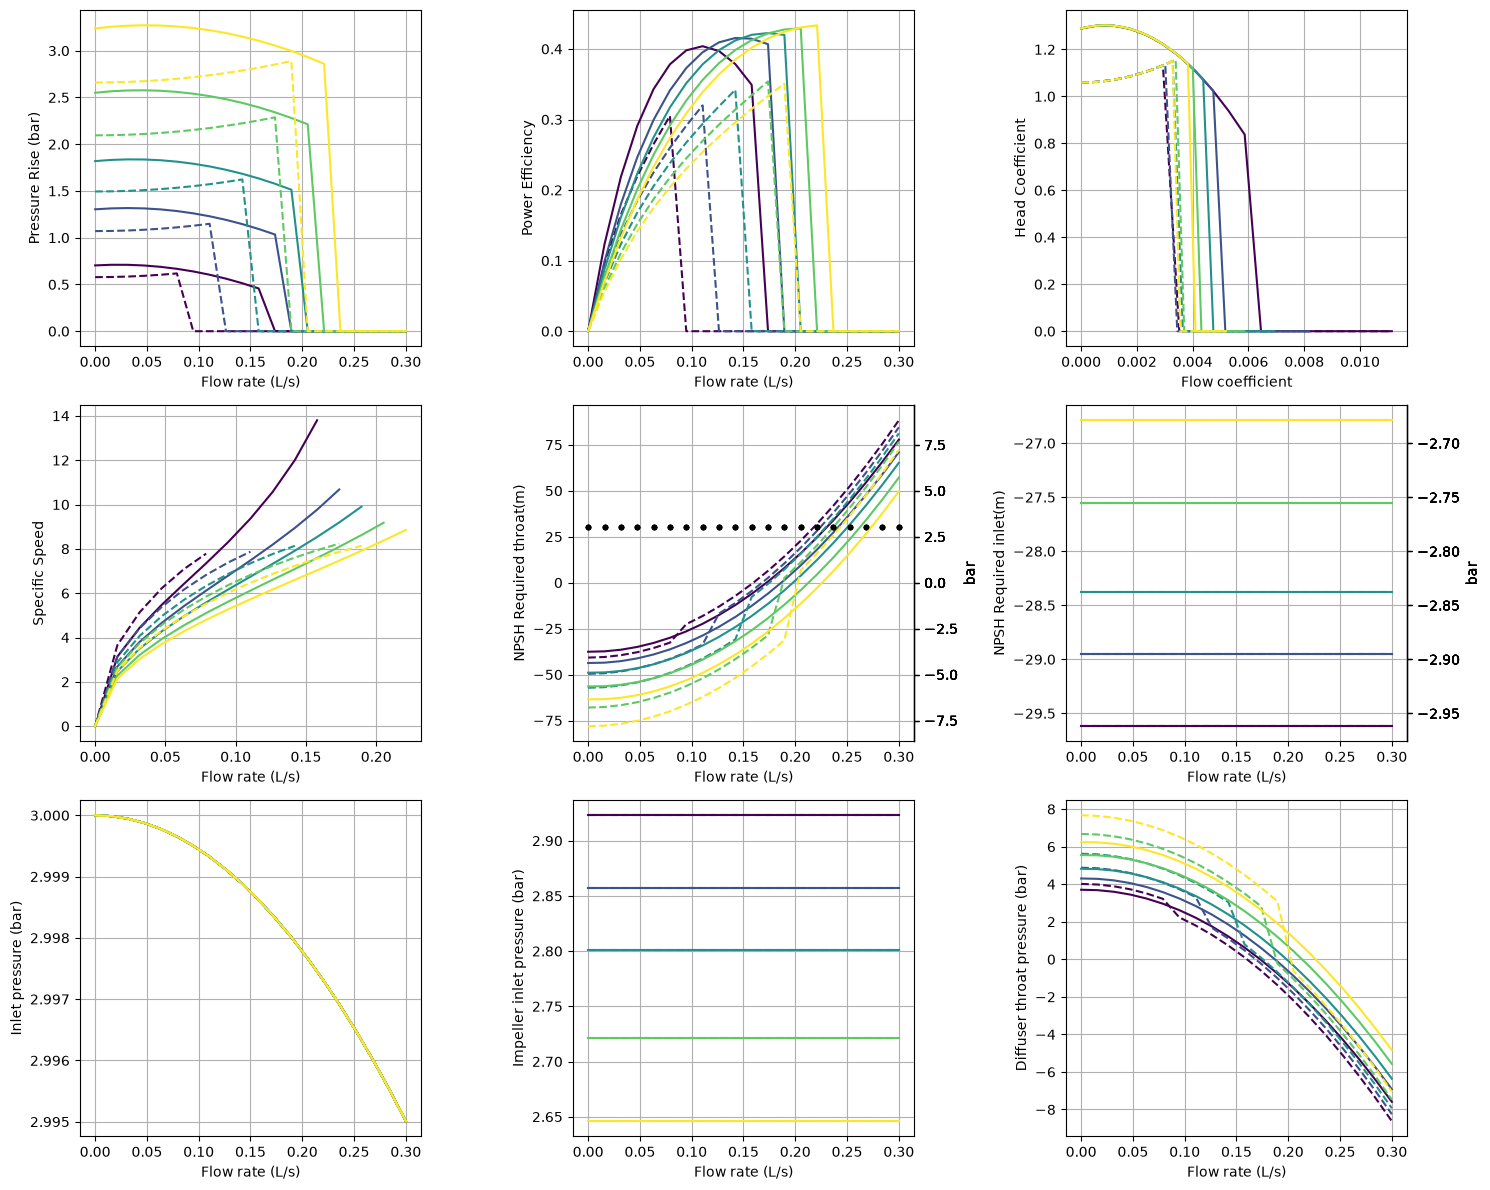

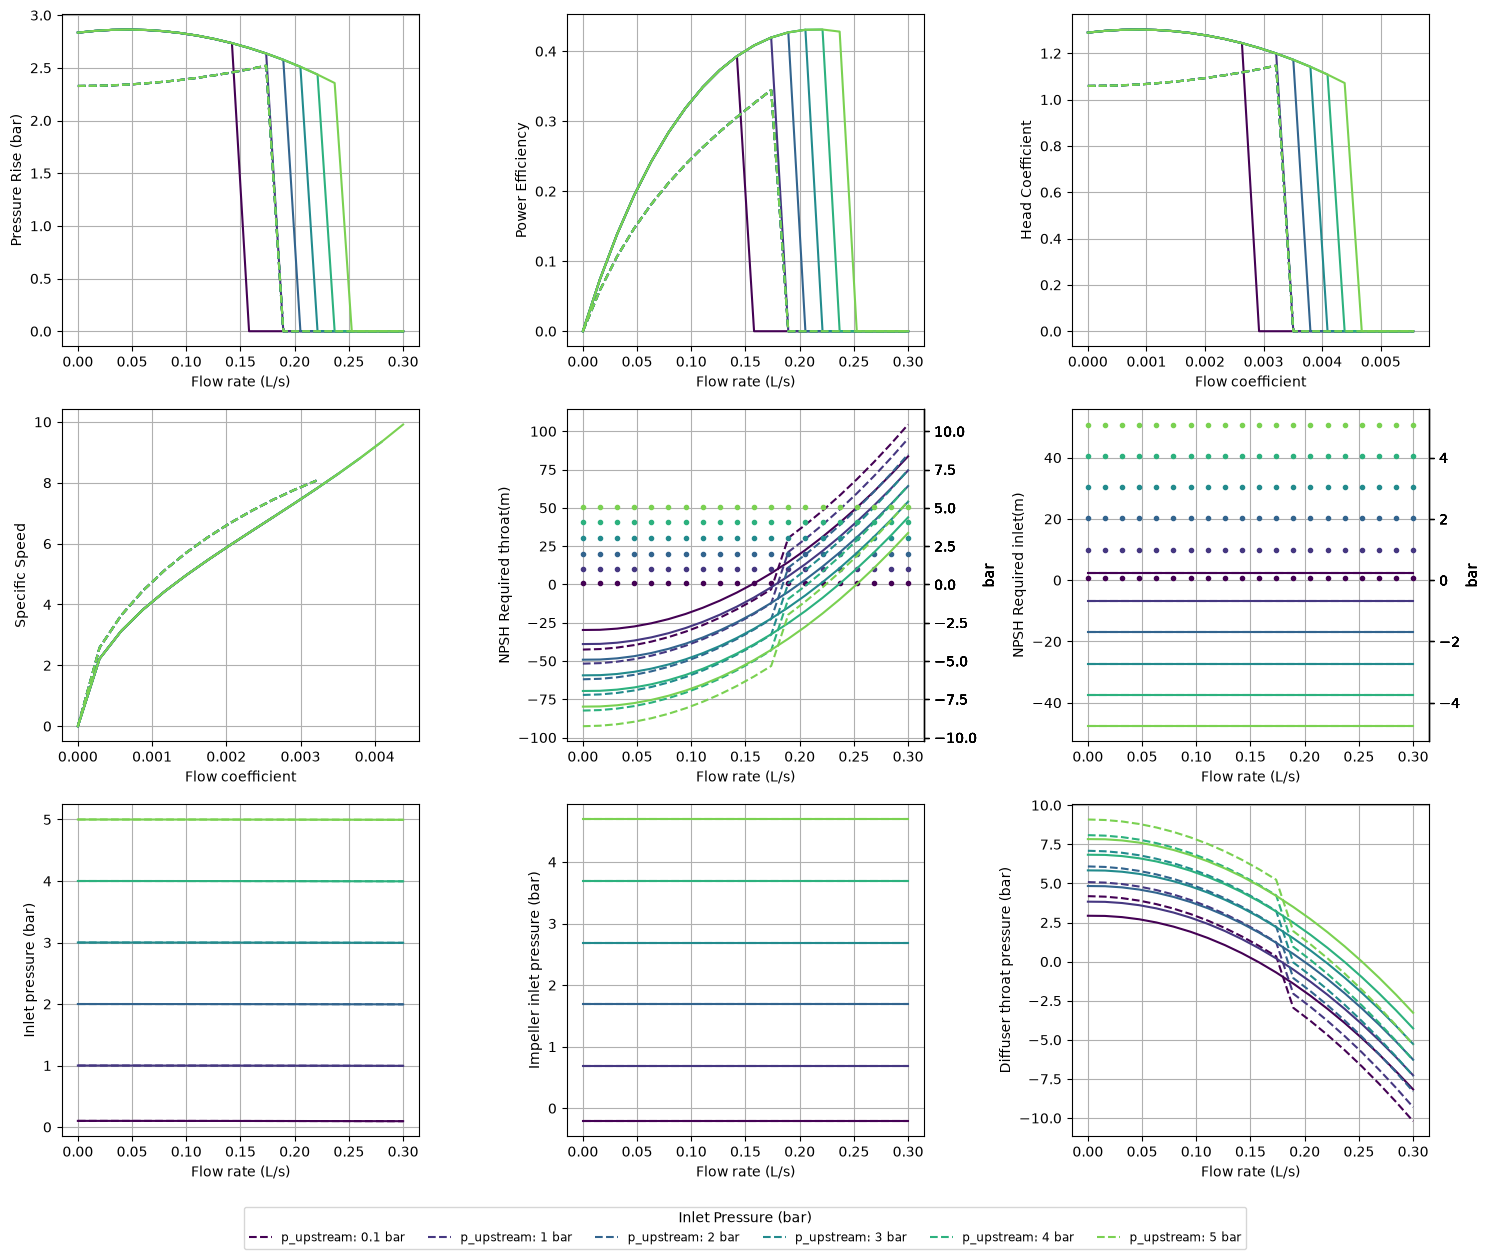

In [133]:
water = Propellant("N/A", FluidsList.Water, t_tank=293.15, p_tank=3)
water_pump_req = PumpRequirements(water, Q_req=0.0003, H_req=200)
water_pump_choices = PumpChoices(rpm=20000, n_blades=6)
water_pump_geometry = size_pump(water_pump_req, water_pump_choices, sizing_method="barske")
water_pump = Pump(water_pump_req, water_pump_choices, water_pump_geometry)
water_pump_perf = water_pump.point_performance(propellant=water, Q=water_pump_req.Q_req, rpm=water_pump_choices.rpm, p_upstream=water.p_tank, T_upstream=water.t_tank, method="barske")
# print(water_pump_perf)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axs = axes.flat
rpms = [3488, 4747, 5608, 6640, 7482]
colors = plt.cm.viridis(np.linspace(0, 1, len(rpms)))
Qs = np.linspace(0, 0.0003, 20)
for ax in axs:
    ax.grid()

for rpm in rpms:
    perfs_barske = []
    perfs_lock = []
    for Q in Qs:
        perf_barske = water_pump.point_performance(propellant=water, Q=Q, rpm=rpm, p_upstream=water.p_tank, T_upstream=water.t_tank, method="barske")
        perfs_barske.append(perf_barske)
        perf_lock = water_pump.point_performance(propellant=water, Q=Q, rpm=rpm, p_upstream=water.p_tank, T_upstream=water.t_tank, method="lock")
        perfs_lock.append(perf_lock)

    axs[0].set_ylabel("Pressure Rise (bar)")
    axs[0].set_xlabel("Flow rate (L/s)")
    axs[0].plot([p.Q * 1000 for p in perfs_barske], [p.dp for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[0].plot([p.Q * 1000 for p in perfs_lock], [p.dp for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[1].set_ylabel("Power Efficiency")
    axs[1].set_xlabel("Flow rate (L/s)")
    axs[1].plot([p.Q * 1000 for p in perfs_barske], [p.eta_power for p in perfs_barske],  "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[1].plot([p.Q * 1000 for p in perfs_lock], [p.eta_power for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[2].set_ylabel("Head Coefficient")
    axs[2].set_xlabel("Flow coefficient")
    axs[2].plot([p.flow_coeff_outlet for p in perfs_barske], [p.head_coeff for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[2].plot([p.flow_coeff_outlet for p in perfs_lock], [p.head_coeff for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[3].set_ylabel("Specific Speed")
    axs[3].set_xlabel("Flow rate (L/s)")
    axs[3].plot([p.Q * 1000 for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[3].plot([p.Q * 1000 for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].set_ylabel("NPSH Required throat(m)")
    axs[4].set_xlabel("Flow rate (L/s)")
    axs4_2 = axs[4].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs4_2.set_ylabel("bar")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_throat for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_throat for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    # axs[4].hlines(y=water_pump_perf.npsh_a_upstream, xmin=0, xmax=0.3, colors="k", linestyles="--", label="NPSH_Available")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", color="k")
    axs[5].set_ylabel("NPSH Required inlet(m)")
    axs[5].set_xlabel("Flow rate (L/s)")
    axs5_2 = axs[5].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs5_2.set_ylabel("bar")
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_inlet for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[5].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_inlet for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[6].set_ylabel("Inlet pressure (bar)")
    axs[6].set_xlabel("Flow rate (L/s)")
    axs[6].plot([p.Q * 1000 for p in perfs_barske], [p.p_inlet for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[6].plot([p.Q * 1000 for p in perfs_lock], [p.p_inlet for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[7].set_ylabel("Impeller inlet pressure (bar)")
    axs[7].set_xlabel("Flow rate (L/s)")
    axs[7].plot([p.Q * 1000 for p in perfs_barske], [p.p_1 for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[7].plot([p.Q * 1000 for p in perfs_lock], [p.p_1 for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[8].set_ylabel("Diffuser throat pressure (bar)")
    axs[8].set_xlabel("Flow rate (L/s)")
    axs[8].plot([p.Q * 1000 for p in perfs_barske], [p.p_throat for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[8].plot([p.Q * 1000 for p in perfs_lock], [p.p_throat for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
plt.tight_layout()


figs, axes = plt.subplots(3, 3, figsize=(15, 12))
axs = axes.flat
inlet_pressures = [0.1, 1, 2, 3, 4, 5]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(inlet_pressures)))
rpm = 7000
Qs = np.linspace(0, 0.0003, 20)


for p_upstream in inlet_pressures:
    perfs_barske = []
    perfs_lock = []
    for Q in Qs:
        perf_barske = water_pump.point_performance(propellant=water, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=water.t_tank, method="barske")
        perfs_barske.append(perf_barske)
        perf_lock = water_pump.point_performance(propellant=water, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=water.t_tank, method="lock")
        perfs_lock.append(perf_lock)

    axs[0].set_ylabel("Pressure Rise (bar)")
    axs[0].set_xlabel("Flow rate (L/s)")
    axs[0].plot([p.Q * 1000 for p in perfs_barske], [p.dp for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[0].plot([p.Q * 1000 for p in perfs_lock], [p.dp for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[1].set_ylabel("Power Efficiency")
    axs[1].set_xlabel("Flow rate (L/s)")
    axs[1].plot([p.Q * 1000 for p in perfs_barske], [p.eta_power for p in perfs_barske],  "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[1].plot([p.Q * 1000 for p in perfs_lock], [p.eta_power for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[2].set_ylabel("Head Coefficient")
    axs[2].set_xlabel("Flow coefficient")
    axs[2].plot([p.flow_coeff_outlet for p in perfs_barske], [p.head_coeff for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[2].plot([p.flow_coeff_outlet for p in perfs_lock], [p.head_coeff for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[3].set_ylabel("Specific Speed")
    axs[3].set_xlabel("Flow coefficient")
    axs[3].plot([p.flow_coeff_outlet for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[3].plot([p.flow_coeff_outlet for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].set_ylabel("NPSH Required throat(m)")
    axs[4].set_xlabel("Flow rate (L/s)")
    axs4_2 = axs[4].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs4_2.set_ylabel("bar")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_throat for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_throat for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].set_ylabel("NPSH Required inlet(m)")
    axs[5].set_xlabel("Flow rate (L/s)")
    axs5_2 = axs[5].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs5_2.set_ylabel("bar")
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_inlet for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_inlet for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[6].set_ylabel("Inlet pressure (bar)")
    axs[6].set_xlabel("Flow rate (L/s)")
    axs[6].plot([p.Q * 1000 for p in perfs_barske], [p.p_inlet for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[6].plot([p.Q * 1000 for p in perfs_lock], [p.p_inlet for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[7].set_ylabel("Impeller inlet pressure (bar)")
    axs[7].set_xlabel("Flow rate (L/s)")
    axs[7].plot([p.Q * 1000 for p in perfs_barske], [p.p_1 for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[7].plot([p.Q * 1000 for p in perfs_lock], [p.p_1 for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[8].set_ylabel("Diffuser throat pressure (bar)")
    axs[8].set_xlabel("Flow rate (L/s)")
    axs[8].plot([p.Q * 1000 for p in perfs_barske], [p.p_throat for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[8].plot([p.Q * 1000 for p in perfs_lock], [p.p_throat for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])

for ax in axs:
    ax.grid()
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles[::2], labels[::2])  # Display every second label (p_upstream colors)

# in legend, only display p_upstream colors, only for solid lines draw one legend at the bottom of the figure for all subplots
handles, labels = axs[0].get_legend_handles_labels()
figs.legend(handles[::2], labels[::2], loc='lower center', ncol=len(inlet_pressures), title="Inlet Pressure (bar)", bbox_to_anchor=(0.5, -0.05), fontsize='small')

figs.tight_layout()

C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3745666166.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.Q * 1000 for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3745666166.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.Q * 1000 for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3745666166.py:102: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.flow_coeff_outlet for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
C:\Users\Martin\AppData\Local\Temp\ipyke

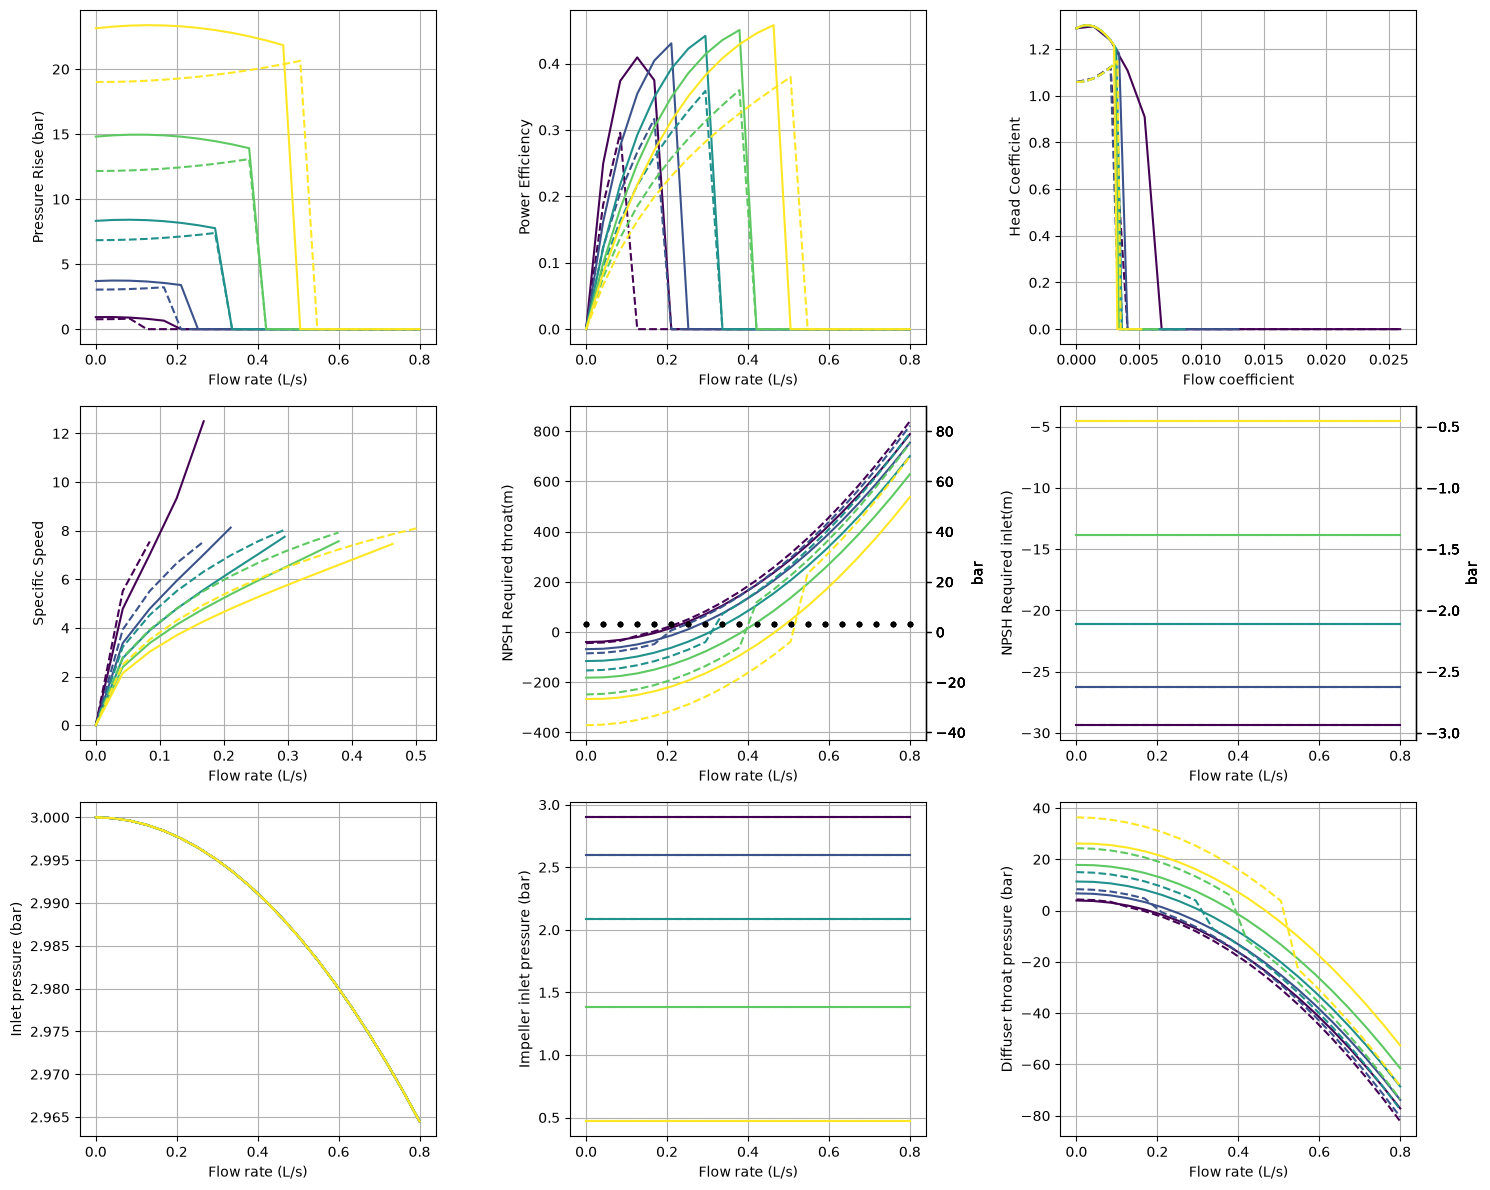

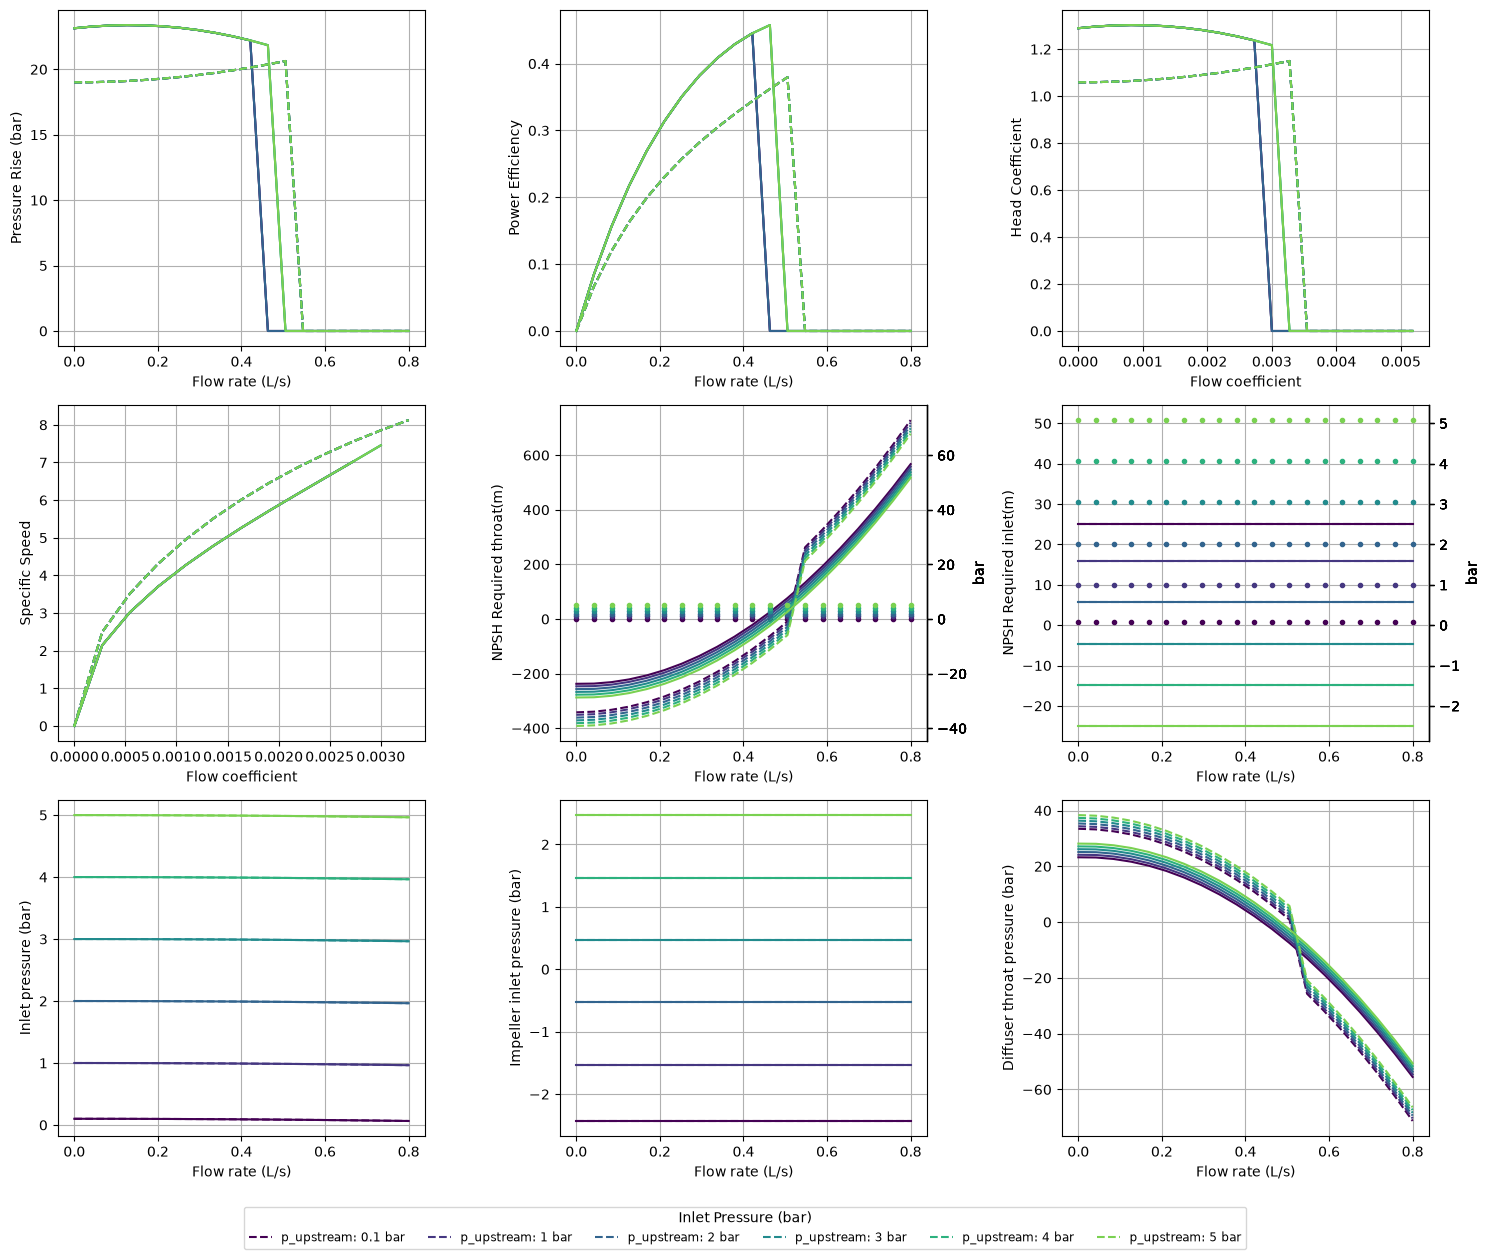

In [137]:
water = Propellant("N/A", FluidsList.Water, t_tank=293.15, p_tank=3)
water_pump_req = PumpRequirements(water, Q_req=0.0003, H_req=200)
water_pump_choices = PumpChoices(rpm=20000, n_blades=6)
water_pump_geometry = size_pump(water_pump_req, water_pump_choices, sizing_method="barske")
water_pump = Pump(water_pump_req, water_pump_choices, water_pump_geometry)
water_pump_perf = water_pump.point_performance(propellant=water, Q=water_pump_req.Q_req, rpm=water_pump_choices.rpm, p_upstream=water.p_tank, T_upstream=water.t_tank, method="barske")
# print(water_pump_perf)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axs = axes.flat
rpms = [4000, 8000, 12000, 16000, 20000]
colors = plt.cm.viridis(np.linspace(0, 1, len(rpms)))
Qs = np.linspace(0, 0.0008, 20)
for ax in axs:
    ax.grid()

for rpm in rpms:
    perfs_barske = []
    perfs_lock = []
    for Q in Qs:
        perf_barske = water_pump.point_performance(propellant=water, Q=Q, rpm=rpm, p_upstream=water.p_tank, T_upstream=water.t_tank, method="barske")
        perfs_barske.append(perf_barske)
        perf_lock = water_pump.point_performance(propellant=water, Q=Q, rpm=rpm, p_upstream=water.p_tank, T_upstream=water.t_tank, method="lock")
        perfs_lock.append(perf_lock)

    axs[0].set_ylabel("Pressure Rise (bar)")
    axs[0].set_xlabel("Flow rate (L/s)")
    axs[0].plot([p.Q * 1000 for p in perfs_barske], [p.dp for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[0].plot([p.Q * 1000 for p in perfs_lock], [p.dp for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[1].set_ylabel("Power Efficiency")
    axs[1].set_xlabel("Flow rate (L/s)")
    axs[1].plot([p.Q * 1000 for p in perfs_barske], [p.eta_power for p in perfs_barske],  "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[1].plot([p.Q * 1000 for p in perfs_lock], [p.eta_power for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[2].set_ylabel("Head Coefficient")
    axs[2].set_xlabel("Flow coefficient")
    axs[2].plot([p.flow_coeff_outlet for p in perfs_barske], [p.head_coeff for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[2].plot([p.flow_coeff_outlet for p in perfs_lock], [p.head_coeff for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[3].set_ylabel("Specific Speed")
    axs[3].set_xlabel("Flow rate (L/s)")
    axs[3].plot([p.Q * 1000 for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[3].plot([p.Q * 1000 for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].set_ylabel("NPSH Required throat(m)")
    axs[4].set_xlabel("Flow rate (L/s)")
    axs4_2 = axs[4].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs4_2.set_ylabel("bar")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_throat for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_throat for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    # axs[4].hlines(y=water_pump_perf.npsh_a_upstream, xmin=0, xmax=0.3, colors="k", linestyles="--", label="NPSH_Available")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", color="k")
    axs[5].set_ylabel("NPSH Required inlet(m)")
    axs[5].set_xlabel("Flow rate (L/s)")
    axs5_2 = axs[5].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs5_2.set_ylabel("bar")
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_inlet for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[5].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_inlet for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[6].set_ylabel("Inlet pressure (bar)")
    axs[6].set_xlabel("Flow rate (L/s)")
    axs[6].plot([p.Q * 1000 for p in perfs_barske], [p.p_inlet for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[6].plot([p.Q * 1000 for p in perfs_lock], [p.p_inlet for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[7].set_ylabel("Impeller inlet pressure (bar)")
    axs[7].set_xlabel("Flow rate (L/s)")
    axs[7].plot([p.Q * 1000 for p in perfs_barske], [p.p_1 for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[7].plot([p.Q * 1000 for p in perfs_lock], [p.p_1 for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[8].set_ylabel("Diffuser throat pressure (bar)")
    axs[8].set_xlabel("Flow rate (L/s)")
    axs[8].plot([p.Q * 1000 for p in perfs_barske], [p.p_throat for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[8].plot([p.Q * 1000 for p in perfs_lock], [p.p_throat for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
plt.tight_layout()


figs, axes = plt.subplots(3, 3, figsize=(15, 12))
axs = axes.flat
inlet_pressures = [0.1, 1, 2, 3, 4, 5]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(inlet_pressures)))
rpm = 20000
Qs = np.linspace(0, 0.0008, 20)


for p_upstream in inlet_pressures:
    perfs_barske = []
    perfs_lock = []
    for Q in Qs:
        perf_barske = water_pump.point_performance(propellant=water, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=water.t_tank, method="barske")
        perfs_barske.append(perf_barske)
        perf_lock = water_pump.point_performance(propellant=water, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=water.t_tank, method="lock")
        perfs_lock.append(perf_lock)

    axs[0].set_ylabel("Pressure Rise (bar)")
    axs[0].set_xlabel("Flow rate (L/s)")
    axs[0].plot([p.Q * 1000 for p in perfs_barske], [p.dp for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[0].plot([p.Q * 1000 for p in perfs_lock], [p.dp for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[1].set_ylabel("Power Efficiency")
    axs[1].set_xlabel("Flow rate (L/s)")
    axs[1].plot([p.Q * 1000 for p in perfs_barske], [p.eta_power for p in perfs_barske],  "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[1].plot([p.Q * 1000 for p in perfs_lock], [p.eta_power for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[2].set_ylabel("Head Coefficient")
    axs[2].set_xlabel("Flow coefficient")
    axs[2].plot([p.flow_coeff_outlet for p in perfs_barske], [p.head_coeff for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[2].plot([p.flow_coeff_outlet for p in perfs_lock], [p.head_coeff for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[3].set_ylabel("Specific Speed")
    axs[3].set_xlabel("Flow coefficient")
    axs[3].plot([p.flow_coeff_outlet for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[3].plot([p.flow_coeff_outlet for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].set_ylabel("NPSH Required throat(m)")
    axs[4].set_xlabel("Flow rate (L/s)")
    axs4_2 = axs[4].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs4_2.set_ylabel("bar")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_throat for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_throat for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].set_ylabel("NPSH Required inlet(m)")
    axs[5].set_xlabel("Flow rate (L/s)")
    axs5_2 = axs[5].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs5_2.set_ylabel("bar")
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_inlet for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_inlet for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[6].set_ylabel("Inlet pressure (bar)")
    axs[6].set_xlabel("Flow rate (L/s)")
    axs[6].plot([p.Q * 1000 for p in perfs_barske], [p.p_inlet for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[6].plot([p.Q * 1000 for p in perfs_lock], [p.p_inlet for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[7].set_ylabel("Impeller inlet pressure (bar)")
    axs[7].set_xlabel("Flow rate (L/s)")
    axs[7].plot([p.Q * 1000 for p in perfs_barske], [p.p_1 for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[7].plot([p.Q * 1000 for p in perfs_lock], [p.p_1 for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[8].set_ylabel("Diffuser throat pressure (bar)")
    axs[8].set_xlabel("Flow rate (L/s)")
    axs[8].plot([p.Q * 1000 for p in perfs_barske], [p.p_throat for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[8].plot([p.Q * 1000 for p in perfs_lock], [p.p_throat for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])

for ax in axs:
    ax.grid()
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles[::2], labels[::2])  # Display every second label (p_upstream colors)

# in legend, only display p_upstream colors, only for solid lines draw one legend at the bottom of the figure for all subplots
handles, labels = axs[0].get_legend_handles_labels()
figs.legend(handles[::2], labels[::2], loc='lower center', ncol=len(inlet_pressures), title="Inlet Pressure (bar)", bbox_to_anchor=(0.5, -0.05), fontsize='small')

figs.tight_layout()

C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3270859142.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.Q * 1000 for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3270859142.py:49: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.Q * 1000 for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3270859142.py:115: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.flow_coeff_outlet for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
C:\Users\Martin\AppData\Local\Temp\ipyke

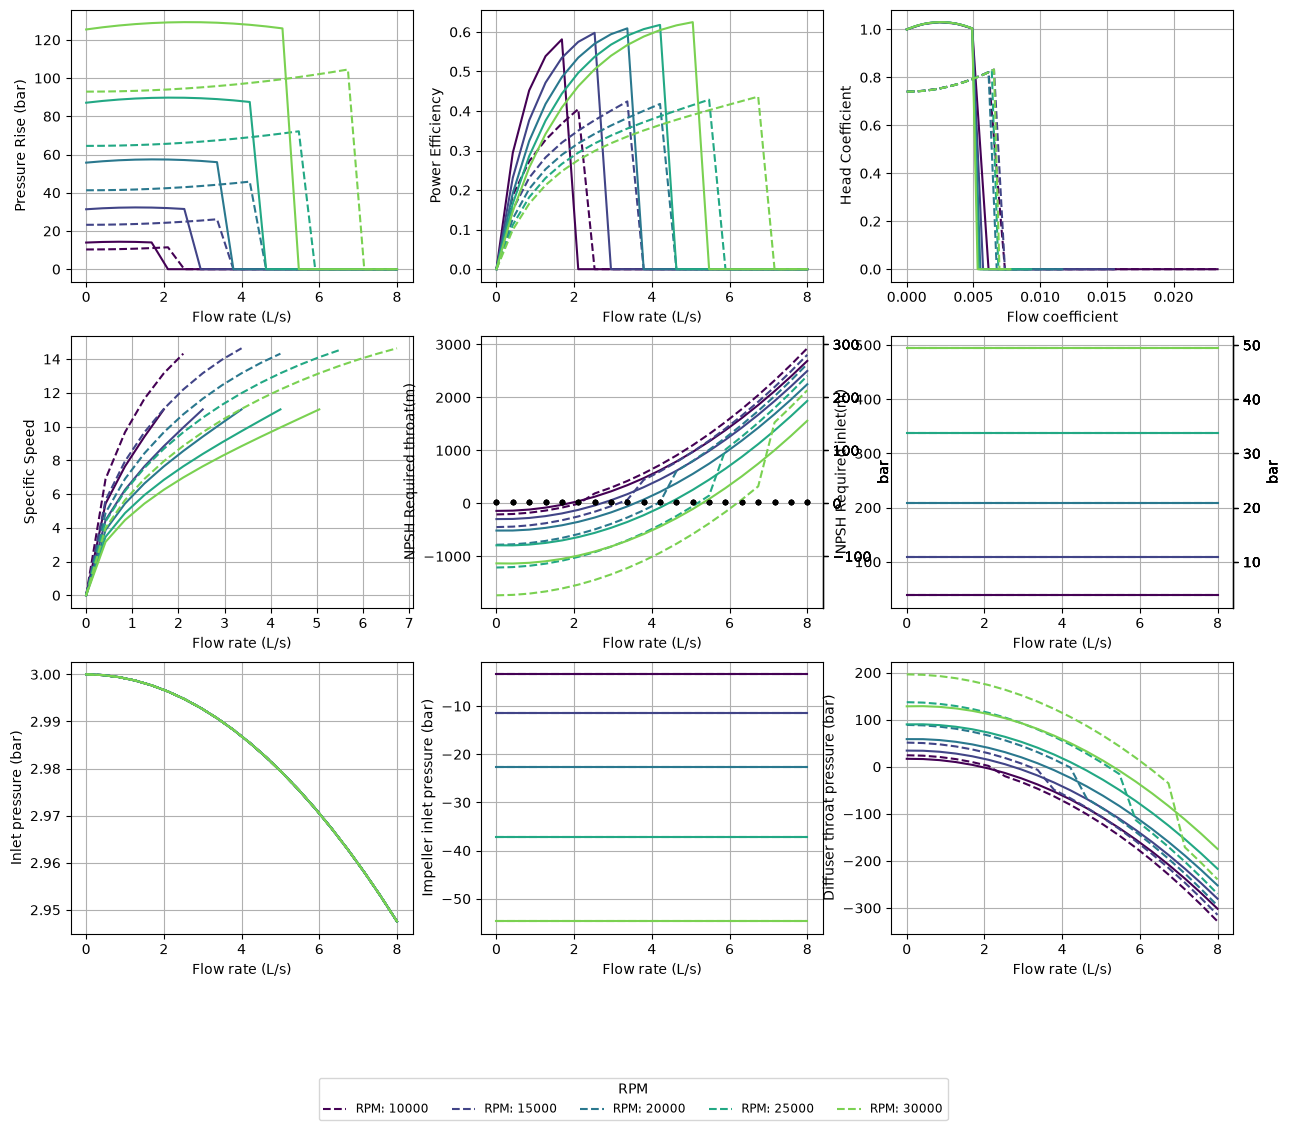

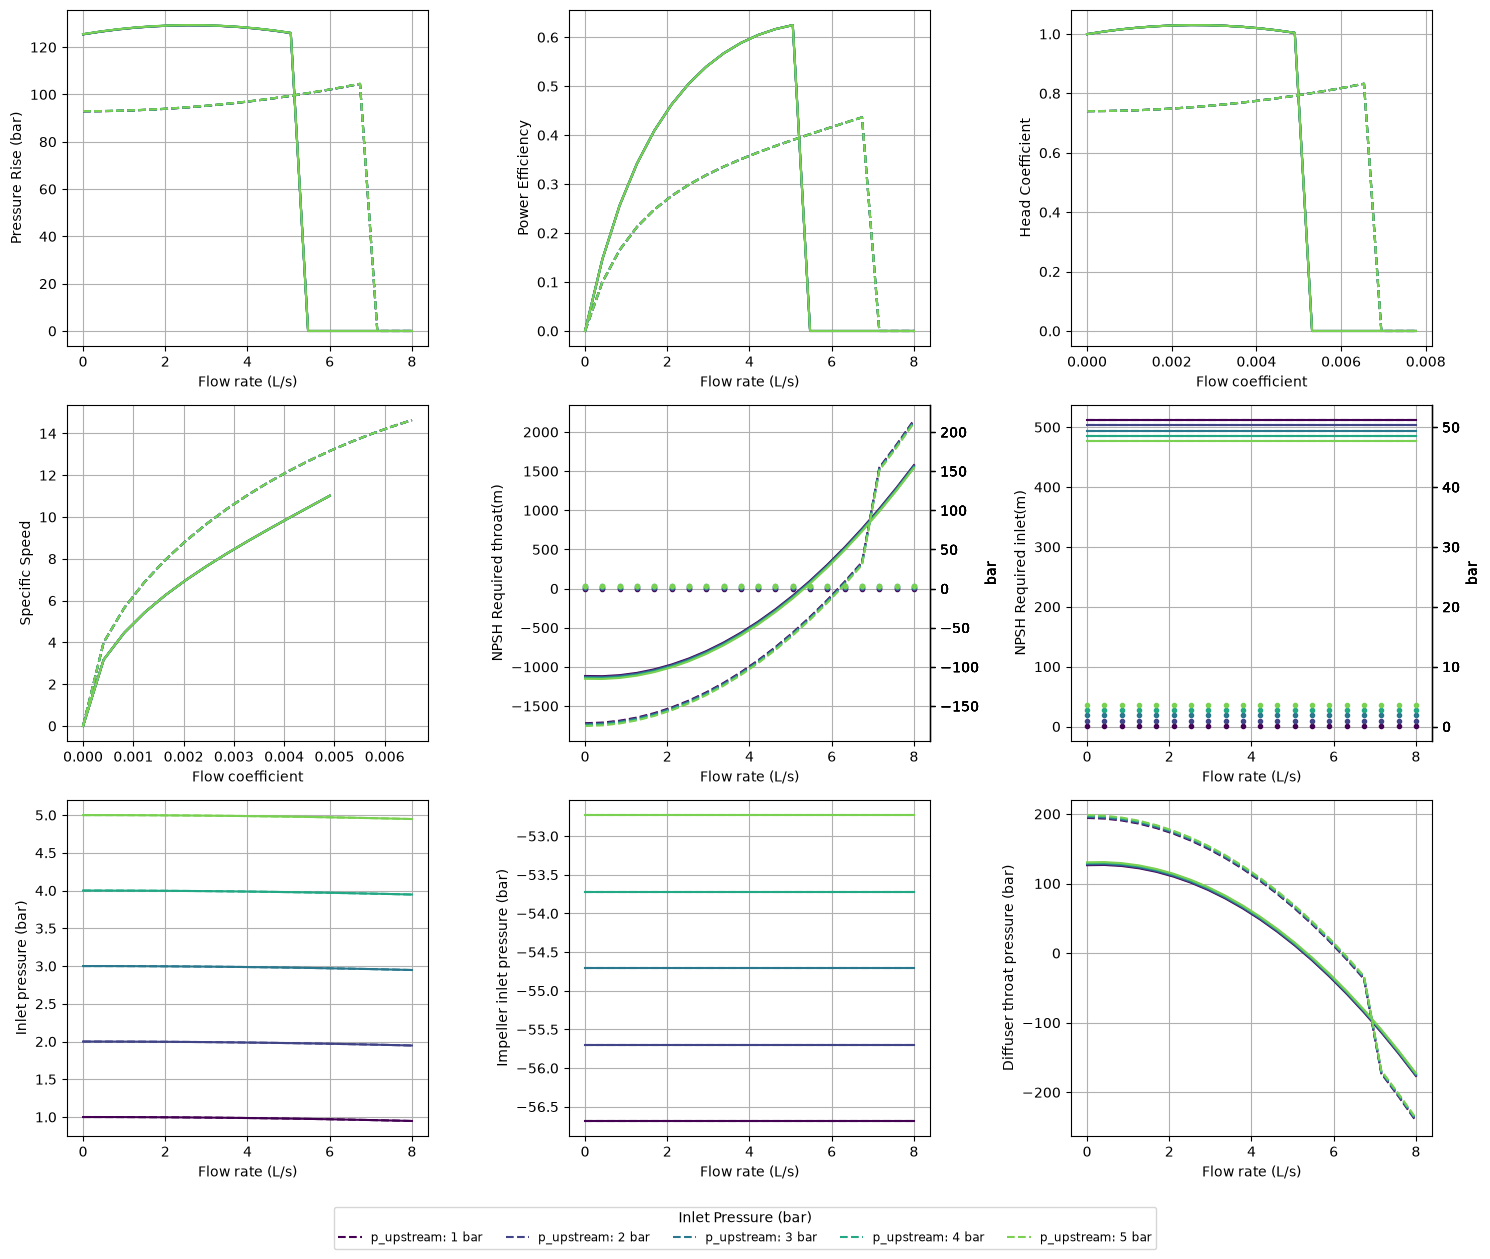

In [146]:
lox = Propellant("LOX", FluidsList.Oxygen, t_tank=89, p_tank=3)
rp1 = Propellant("RP-1", FluidsList.nDodecane, t_tank=293.15, p_tank=3)

propcea = PropCEA(lox, rp1)
engine_req = EngineRequirements(F=12000, p_a_bar=1.01325)
engine_choices = EngineChoices(OF=2, p_c_bar=50, p_e_bar=1, perc_film=0.1)
injector_choices = InjectorChoices(inj_dp=10, fuel_cd=0.8, ox_cd=0.8)
engine_calib = EngineCalibration(eff_cstar=0.95)
chamber, injector = size_engine(engine_req, engine_choices, injector_choices, engine_calib, propcea)
engine = Engine(chamber, injector, propcea, engine_calib)
engine_perf = engine.point_performance(p_c_bar=50, p_a_bar=1.01325, OF=2)
ox_pump_req = PumpRequirements.from_engine_perf(engine_perf, "ox")
ox_pump_choices = PumpChoices(rpm=20000, n_blades=6)
ox_pump_geometry = size_pump(ox_pump_req, ox_pump_choices, sizing_method="lock")
ox_pump = Pump(ox_pump_req, ox_pump_choices, ox_pump_geometry)
ox_pump_perf = ox_pump.point_performance(propellant=lox, Q=ox_pump_req.Q_req, rpm=ox_pump_choices.rpm, p_upstream=lox.p_tank, T_upstream=lox.t_tank, method="lock")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axs = axes.flat
rpms = [10000, 15000, 20000, 25000, 30000]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(rpms)))
Qs = np.linspace(0, 8 / 1000, 20)


for rpm in rpms:
    perfs_barske = []
    perfs_lock = []
    for Q in Qs:
        perf_barske = ox_pump.point_performance(propellant=lox, Q=Q, rpm=rpm, p_upstream=lox.p_tank, T_upstream=lox.t_tank, method="barske")
        perfs_barske.append(perf_barske)
        perf_lock = ox_pump.point_performance(propellant=lox, Q=Q, rpm=rpm, p_upstream=lox.p_tank, T_upstream=lox.t_tank, method="lock")
        perfs_lock.append(perf_lock)

    axs[0].set_ylabel("Pressure Rise (bar)")
    axs[0].set_xlabel("Flow rate (L/s)")
    axs[0].plot([p.Q * 1000 for p in perfs_barske], [p.dp for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[0].plot([p.Q * 1000 for p in perfs_lock], [p.dp for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[1].set_ylabel("Power Efficiency")
    axs[1].set_xlabel("Flow rate (L/s)")
    axs[1].plot([p.Q * 1000 for p in perfs_barske], [p.eta_power for p in perfs_barske],  "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[1].plot([p.Q * 1000 for p in perfs_lock], [p.eta_power for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[2].set_ylabel("Head Coefficient")
    axs[2].set_xlabel("Flow coefficient")
    axs[2].plot([p.flow_coeff_outlet for p in perfs_barske], [p.head_coeff for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[2].plot([p.flow_coeff_outlet for p in perfs_lock], [p.head_coeff for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[3].set_ylabel("Specific Speed")
    axs[3].set_xlabel("Flow rate (L/s)")
    axs[3].plot([p.Q * 1000 for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[3].plot([p.Q * 1000 for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].set_ylabel("NPSH Required throat(m)")
    axs[4].set_xlabel("Flow rate (L/s)")
    axs4_2 = axs[4].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs4_2.set_ylabel("bar")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_throat for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_throat for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", color="k")
    axs[5].set_ylabel("NPSH Required inlet(m)")
    axs[5].set_xlabel("Flow rate (L/s)")
    axs5_2 = axs[5].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs5_2.set_ylabel("bar")
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_inlet for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[5].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_inlet for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[6].set_ylabel("Inlet pressure (bar)")
    axs[6].set_xlabel("Flow rate (L/s)")
    axs[6].plot([p.Q * 1000 for p in perfs_barske], [p.p_inlet for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[6].plot([p.Q * 1000 for p in perfs_lock], [p.p_inlet for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[7].set_ylabel("Impeller inlet pressure (bar)")
    axs[7].set_xlabel("Flow rate (L/s)")
    axs[7].plot([p.Q * 1000 for p in perfs_barske], [p.p_1 for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[7].plot([p.Q * 1000 for p in perfs_lock], [p.p_1 for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[8].set_ylabel("Diffuser throat pressure (bar)")
    axs[8].set_xlabel("Flow rate (L/s)")
    axs[8].plot([p.Q * 1000 for p in perfs_barske], [p.p_throat for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[8].plot([p.Q * 1000 for p in perfs_lock], [p.p_throat for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
for ax in axs:
    ax.grid()
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles[::2], labels[::2])  # Display every second label (rpm colors)

# in legend, only display rpm colors, only for solid lines draw one legend at the bottom of the figure for all subplots  
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles[::2], labels[::2], loc='lower center', ncol=len(rpms), title="RPM", bbox_to_anchor=(0.5, -0.05), fontsize='small')


figs, axes = plt.subplots(3, 3, figsize=(15, 12))
axs = axes.flat
inlet_pressures = [1, 2, 3, 4, 5]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(inlet_pressures)))
rpm = 30000
Qs = np.linspace(0, 8 / 1000, 20)

for p_upstream in inlet_pressures:
    perfs_barske = []
    perfs_lock = []
    for Q in Qs:
        perf_barske = ox_pump.point_performance(propellant=lox, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=lox.t_tank, method="barske")
        perfs_barske.append(perf_barske)
        perf_lock = ox_pump.point_performance(propellant=lox, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=lox.t_tank, method="lock")
        perfs_lock.append(perf_lock)

    axs[0].set_ylabel("Pressure Rise (bar)")
    axs[0].set_xlabel("Flow rate (L/s)")
    axs[0].plot([p.Q * 1000 for p in perfs_barske], [p.dp for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[0].plot([p.Q * 1000 for p in perfs_lock], [p.dp for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[1].set_ylabel("Power Efficiency")
    axs[1].set_xlabel("Flow rate (L/s)")
    axs[1].plot([p.Q * 1000 for p in perfs_barske], [p.eta_power for p in perfs_barske],  "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[1].plot([p.Q * 1000 for p in perfs_lock], [p.eta_power for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[2].set_ylabel("Head Coefficient")
    axs[2].set_xlabel("Flow coefficient")
    axs[2].plot([p.flow_coeff_outlet for p in perfs_barske], [p.head_coeff for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[2].plot([p.flow_coeff_outlet for p in perfs_lock], [p.head_coeff for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[3].set_ylabel("Specific Speed")
    axs[3].set_xlabel("Flow coefficient")
    axs[3].plot([p.flow_coeff_outlet for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[3].plot([p.flow_coeff_outlet for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].set_ylabel("NPSH Required throat(m)")
    axs[4].set_xlabel("Flow rate (L/s)")
    axs4_2 = axs[4].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs4_2.set_ylabel("bar")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_throat for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_throat for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])

    axs[5].set_ylabel("NPSH Required inlet(m)")
    axs[5].set_xlabel("Flow rate (L/s)")
    axs5_2 = axs[5].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs5_2.set_ylabel("bar")
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_inlet for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_inlet for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    
    axs[6].set_ylabel("Inlet pressure (bar)")
    axs[6].set_xlabel("Flow rate (L/s)")
    axs[6].plot([p.Q * 1000 for p in perfs_barske], [p.p_inlet for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[6].plot([p.Q * 1000 for p in perfs_lock], [p.p_inlet for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[7].set_ylabel("Impeller inlet pressure (bar)")
    axs[7].set_xlabel("Flow rate (L/s)")
    axs[7].plot([p.Q * 1000 for p in perfs_barske], [p.p_1 for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[7].plot([p.Q * 1000 for p in perfs_lock], [p.p_1 for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[8].set_ylabel("Diffuser throat pressure (bar)")
    axs[8].set_xlabel("Flow rate (L/s)")
    axs[8].plot([p.Q * 1000 for p in perfs_barske], [p.p_throat for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[8].plot([p.Q * 1000 for p in perfs_lock], [p.p_throat for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])

for ax in axs:
    ax.grid()
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles[::2], labels[::2])  # Display every second label (p_upstream colors)

# in legend, only display p_upstream colors, only for solid lines draw one legend at the bottom of the figure for all subplots
handles, labels = axs[0].get_legend_handles_labels()
figs.legend(handles[::2], labels[::2], loc='lower center', ncol=len(inlet_pressures), title="Inlet Pressure (bar)", bbox_to_anchor=(0.5, -0.05), fontsize='small')

figs.tight_layout()

C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3655639832.py:48: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.Q * 1000 for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3655639832.py:49: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.Q * 1000 for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
C:\Users\Martin\AppData\Local\Temp\ipykernel_34416\3655639832.py:115: RuntimeWarning: divide by zero encountered in scalar divide
  axs[3].plot([p.flow_coeff_outlet for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
C:\Users\Martin\AppData\Local\Temp\ipyke

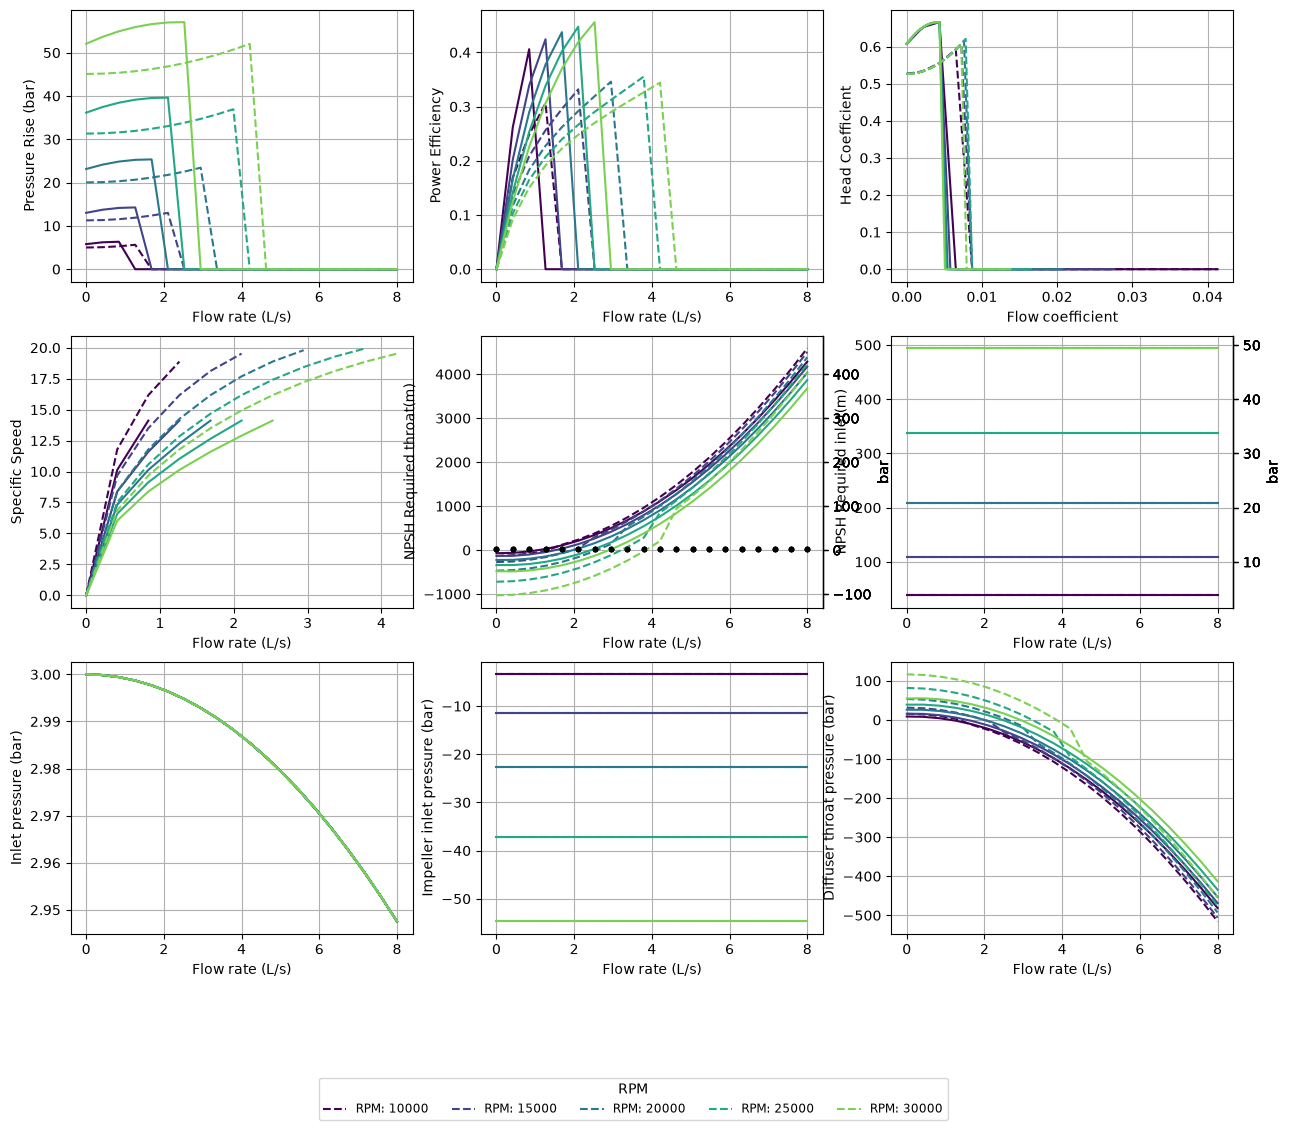

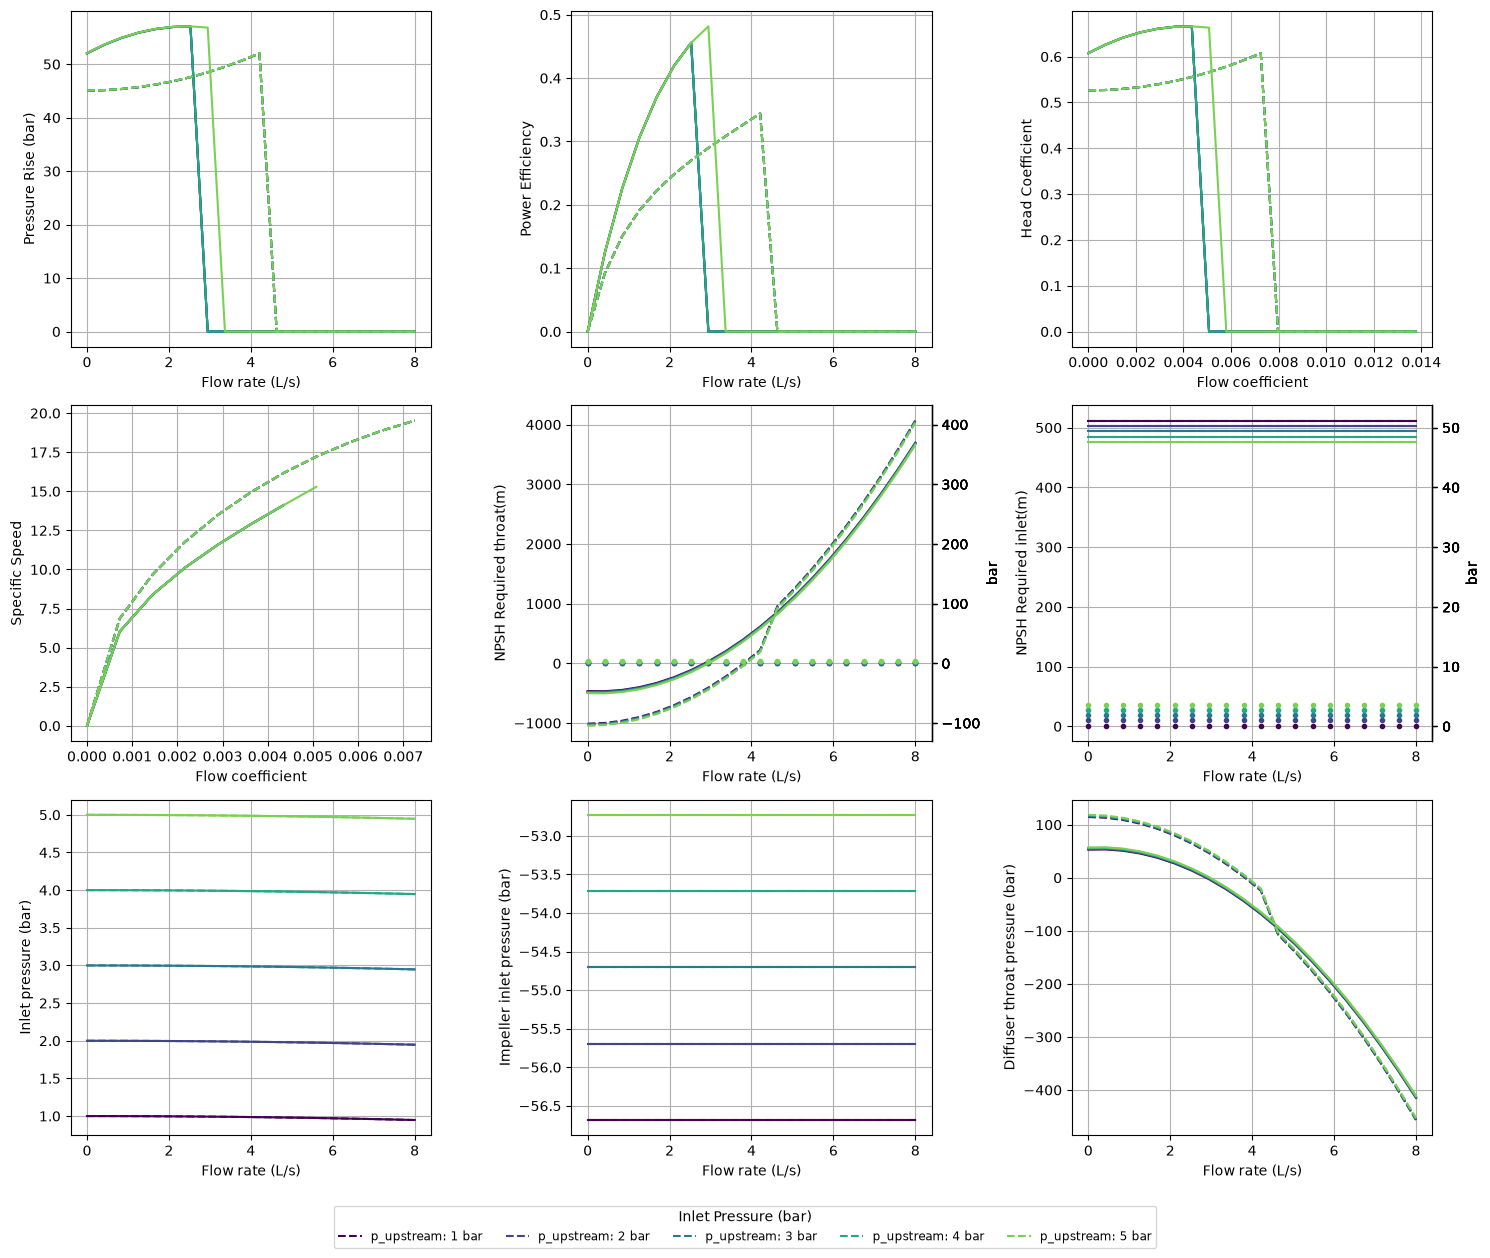

In [134]:
lox = Propellant("LOX", FluidsList.Oxygen, t_tank=89, p_tank=3)
rp1 = Propellant("RP-1", FluidsList.nDodecane, t_tank=293.15, p_tank=3)

propcea = PropCEA(lox, rp1)
engine_req = EngineRequirements(F=12000, p_a_bar=1.01325)
engine_choices = EngineChoices(OF=2, p_c_bar=50, p_e_bar=1, perc_film=0.1)
injector_choices = InjectorChoices(inj_dp=10, fuel_cd=0.8, ox_cd=0.8)
engine_calib = EngineCalibration(eff_cstar=0.95)
chamber, injector = size_engine(engine_req, engine_choices, injector_choices, engine_calib, propcea)
engine = Engine(chamber, injector, propcea, engine_calib)
engine_perf = engine.point_performance(p_c_bar=50, p_a_bar=1.01325, OF=2)
ox_pump_req = PumpRequirements.from_engine_perf(engine_perf, "ox")
ox_pump_choices = PumpChoices(rpm=30000, n_blades=6)
ox_pump_geometry = size_pump(ox_pump_req, ox_pump_choices, sizing_method="lock")
ox_pump = Pump(ox_pump_req, ox_pump_choices, ox_pump_geometry)
ox_pump_perf = ox_pump.point_performance(propellant=lox, Q=ox_pump_req.Q_req, rpm=ox_pump_choices.rpm, p_upstream=lox.p_tank, T_upstream=lox.t_tank, method="lock")

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axs = axes.flat
rpms = [10000, 15000, 20000, 25000, 30000]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(rpms)))
Qs = np.linspace(0, 8 / 1000, 20)


for rpm in rpms:
    perfs_barske = []
    perfs_lock = []
    for Q in Qs:
        perf_barske = ox_pump.point_performance(propellant=lox, Q=Q, rpm=rpm, p_upstream=lox.p_tank, T_upstream=lox.t_tank, method="barske")
        perfs_barske.append(perf_barske)
        perf_lock = ox_pump.point_performance(propellant=lox, Q=Q, rpm=rpm, p_upstream=lox.p_tank, T_upstream=lox.t_tank, method="lock")
        perfs_lock.append(perf_lock)

    axs[0].set_ylabel("Pressure Rise (bar)")
    axs[0].set_xlabel("Flow rate (L/s)")
    axs[0].plot([p.Q * 1000 for p in perfs_barske], [p.dp for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[0].plot([p.Q * 1000 for p in perfs_lock], [p.dp for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[1].set_ylabel("Power Efficiency")
    axs[1].set_xlabel("Flow rate (L/s)")
    axs[1].plot([p.Q * 1000 for p in perfs_barske], [p.eta_power for p in perfs_barske],  "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[1].plot([p.Q * 1000 for p in perfs_lock], [p.eta_power for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[2].set_ylabel("Head Coefficient")
    axs[2].set_xlabel("Flow coefficient")
    axs[2].plot([p.flow_coeff_outlet for p in perfs_barske], [p.head_coeff for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[2].plot([p.flow_coeff_outlet for p in perfs_lock], [p.head_coeff for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[3].set_ylabel("Specific Speed")
    axs[3].set_xlabel("Flow rate (L/s)")
    axs[3].plot([p.Q * 1000 for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[3].plot([p.Q * 1000 for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].set_ylabel("NPSH Required throat(m)")
    axs[4].set_xlabel("Flow rate (L/s)")
    axs4_2 = axs[4].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs4_2.set_ylabel("bar")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_throat for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_throat for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", color="k")
    axs[5].set_ylabel("NPSH Required inlet(m)")
    axs[5].set_xlabel("Flow rate (L/s)")
    axs5_2 = axs[5].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs5_2.set_ylabel("bar")
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_inlet for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[5].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_inlet for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[6].set_ylabel("Inlet pressure (bar)")
    axs[6].set_xlabel("Flow rate (L/s)")
    axs[6].plot([p.Q * 1000 for p in perfs_barske], [p.p_inlet for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[6].plot([p.Q * 1000 for p in perfs_lock], [p.p_inlet for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[7].set_ylabel("Impeller inlet pressure (bar)")
    axs[7].set_xlabel("Flow rate (L/s)")
    axs[7].plot([p.Q * 1000 for p in perfs_barske], [p.p_1 for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[7].plot([p.Q * 1000 for p in perfs_lock], [p.p_1 for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[8].set_ylabel("Diffuser throat pressure (bar)")
    axs[8].set_xlabel("Flow rate (L/s)")
    axs[8].plot([p.Q * 1000 for p in perfs_barske], [p.p_throat for p in perfs_barske], "--", label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
    axs[8].plot([p.Q * 1000 for p in perfs_lock], [p.p_throat for p in perfs_lock], label=f"RPM: {rpm}", color=colors[rpms.index(rpm)])
for ax in axs:
    ax.grid()
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles[::2], labels[::2])  # Display every second label (rpm colors)

# in legend, only display rpm colors, only for solid lines draw one legend at the bottom of the figure for all subplots  
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles[::2], labels[::2], loc='lower center', ncol=len(rpms), title="RPM", bbox_to_anchor=(0.5, -0.05), fontsize='small')


figs, axes = plt.subplots(3, 3, figsize=(15, 12))
axs = axes.flat
inlet_pressures = [1, 2, 3, 4, 5]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(inlet_pressures)))
rpm = 30000
Qs = np.linspace(0, 8 / 1000, 20)

for p_upstream in inlet_pressures:
    perfs_barske = []
    perfs_lock = []
    for Q in Qs:
        perf_barske = ox_pump.point_performance(propellant=lox, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=lox.t_tank, method="barske")
        perfs_barske.append(perf_barske)
        perf_lock = ox_pump.point_performance(propellant=lox, Q=Q, rpm=rpm, p_upstream=p_upstream, T_upstream=lox.t_tank, method="lock")
        perfs_lock.append(perf_lock)

    axs[0].set_ylabel("Pressure Rise (bar)")
    axs[0].set_xlabel("Flow rate (L/s)")
    axs[0].plot([p.Q * 1000 for p in perfs_barske], [p.dp for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[0].plot([p.Q * 1000 for p in perfs_lock], [p.dp for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[1].set_ylabel("Power Efficiency")
    axs[1].set_xlabel("Flow rate (L/s)")
    axs[1].plot([p.Q * 1000 for p in perfs_barske], [p.eta_power for p in perfs_barske],  "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[1].plot([p.Q * 1000 for p in perfs_lock], [p.eta_power for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[2].set_ylabel("Head Coefficient")
    axs[2].set_xlabel("Flow coefficient")
    axs[2].plot([p.flow_coeff_outlet for p in perfs_barske], [p.head_coeff for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[2].plot([p.flow_coeff_outlet for p in perfs_lock], [p.head_coeff for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[3].set_ylabel("Specific Speed")
    axs[3].set_xlabel("Flow coefficient")
    axs[3].plot([p.flow_coeff_outlet for p in perfs_barske], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[3].plot([p.flow_coeff_outlet for p in perfs_lock], [p.rpm * np.sqrt(p.Q) / (p.H_total_real**0.75) for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].set_ylabel("NPSH Required throat(m)")
    axs[4].set_xlabel("Flow rate (L/s)")
    axs4_2 = axs[4].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs4_2.set_ylabel("bar")
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_throat for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_throat for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[4].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])

    axs[5].set_ylabel("NPSH Required inlet(m)")
    axs[5].set_xlabel("Flow rate (L/s)")
    axs5_2 = axs[5].secondary_yaxis("right", functions=(lambda x: x / 10, lambda x: x * 10))
    axs5_2.set_ylabel("bar")
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_r_inlet for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].plot([p.Q * 1000 for p in perfs_lock], [p.npsh_r_inlet for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[5].plot([p.Q * 1000 for p in perfs_barske], [p.npsh_a_upstream for p in perfs_barske], ".", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    
    axs[6].set_ylabel("Inlet pressure (bar)")
    axs[6].set_xlabel("Flow rate (L/s)")
    axs[6].plot([p.Q * 1000 for p in perfs_barske], [p.p_inlet for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[6].plot([p.Q * 1000 for p in perfs_lock], [p.p_inlet for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[7].set_ylabel("Impeller inlet pressure (bar)")
    axs[7].set_xlabel("Flow rate (L/s)")
    axs[7].plot([p.Q * 1000 for p in perfs_barske], [p.p_1 for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[7].plot([p.Q * 1000 for p in perfs_lock], [p.p_1 for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[8].set_ylabel("Diffuser throat pressure (bar)")
    axs[8].set_xlabel("Flow rate (L/s)")
    axs[8].plot([p.Q * 1000 for p in perfs_barske], [p.p_throat for p in perfs_barske], "--", label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])
    axs[8].plot([p.Q * 1000 for p in perfs_lock], [p.p_throat for p in perfs_lock], label=f"p_upstream: {p_upstream} bar", color=colors[inlet_pressures.index(p_upstream)])

for ax in axs:
    ax.grid()
    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(handles[::2], labels[::2])  # Display every second label (p_upstream colors)

# in legend, only display p_upstream colors, only for solid lines draw one legend at the bottom of the figure for all subplots
handles, labels = axs[0].get_legend_handles_labels()
figs.legend(handles[::2], labels[::2], loc='lower center', ncol=len(inlet_pressures), title="Inlet Pressure (bar)", bbox_to_anchor=(0.5, -0.05), fontsize='small')

figs.tight_layout()

In [156]:
from dataclasses import dataclass
from typing import Callable, Optional

@dataclass
class Panel:
    ylabel: str
    xlabel: str
    x: Callable                        # perf -> x
    y: Callable                        # perf -> y
    ref:  Optional[Callable] = None    # perf -> horizontal reference, drawn per curve (e.g. NPSHa)
    mask: Optional[Callable] = None    # perf -> keep?  False points become gaps (e.g. post-cutoff)
    secondary: Optional[tuple] = None  # (label, fwd, inv) right-hand axis

_LINESTYLES = {"lock": "-", "barske": "--", "barske_simple": ":"}

def sweep_plot(pump, panels, Qs, sweep, fixed, methods=("lock",), ncols=3, figsize=None, cmap="viridis"):
    name, values = sweep
    nrows = -(-len(panels) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize or (5*ncols, 4*nrows))
    axs = list(axes.flat)
    colors = plt.get_cmap(cmap)(np.linspace(0, 0.85, len(values)))

    for vi, val in enumerate(values):
        for method in methods:
            perfs = [pump.point_performance(**dict(fixed, Q=Q, method=method, **{name: val})) for Q in Qs]
            ls = _LINESTYLES.get(method, "-")
            first = method == methods[0]
            for panel, ax in zip(panels, axs):
                ys = np.array([panel.y(p) for p in perfs], float)
                if panel.mask is not None:
                    ys = np.where([bool(panel.mask(p)) for p in perfs], ys, np.nan)
                ax.plot([panel.x(p) for p in perfs], ys, ls, color=colors[vi],
                        label=f"{name} {val}" if first else None)
                if panel.ref is not None and first:
                    ax.axhline(panel.ref(perfs[0]), color=colors[vi], ls=":", lw=2)

    for panel, ax in zip(panels, axs):
        ax.set_xlabel(panel.xlabel); ax.set_ylabel(panel.ylabel); ax.grid(True)
        if panel.secondary:
            lbl, fwd, inv = panel.secondary
            ax.secondary_yaxis("right", functions=(fwd, inv)).set_ylabel(lbl)
    for ax in list(axs)[len(panels):]:
        ax.set_visible(False)

    h, l = axs[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=len(values), title=name,
               bbox_to_anchor=(0.5, -0.04), fontsize="small")
    fig.tight_layout()
    return fig

Done


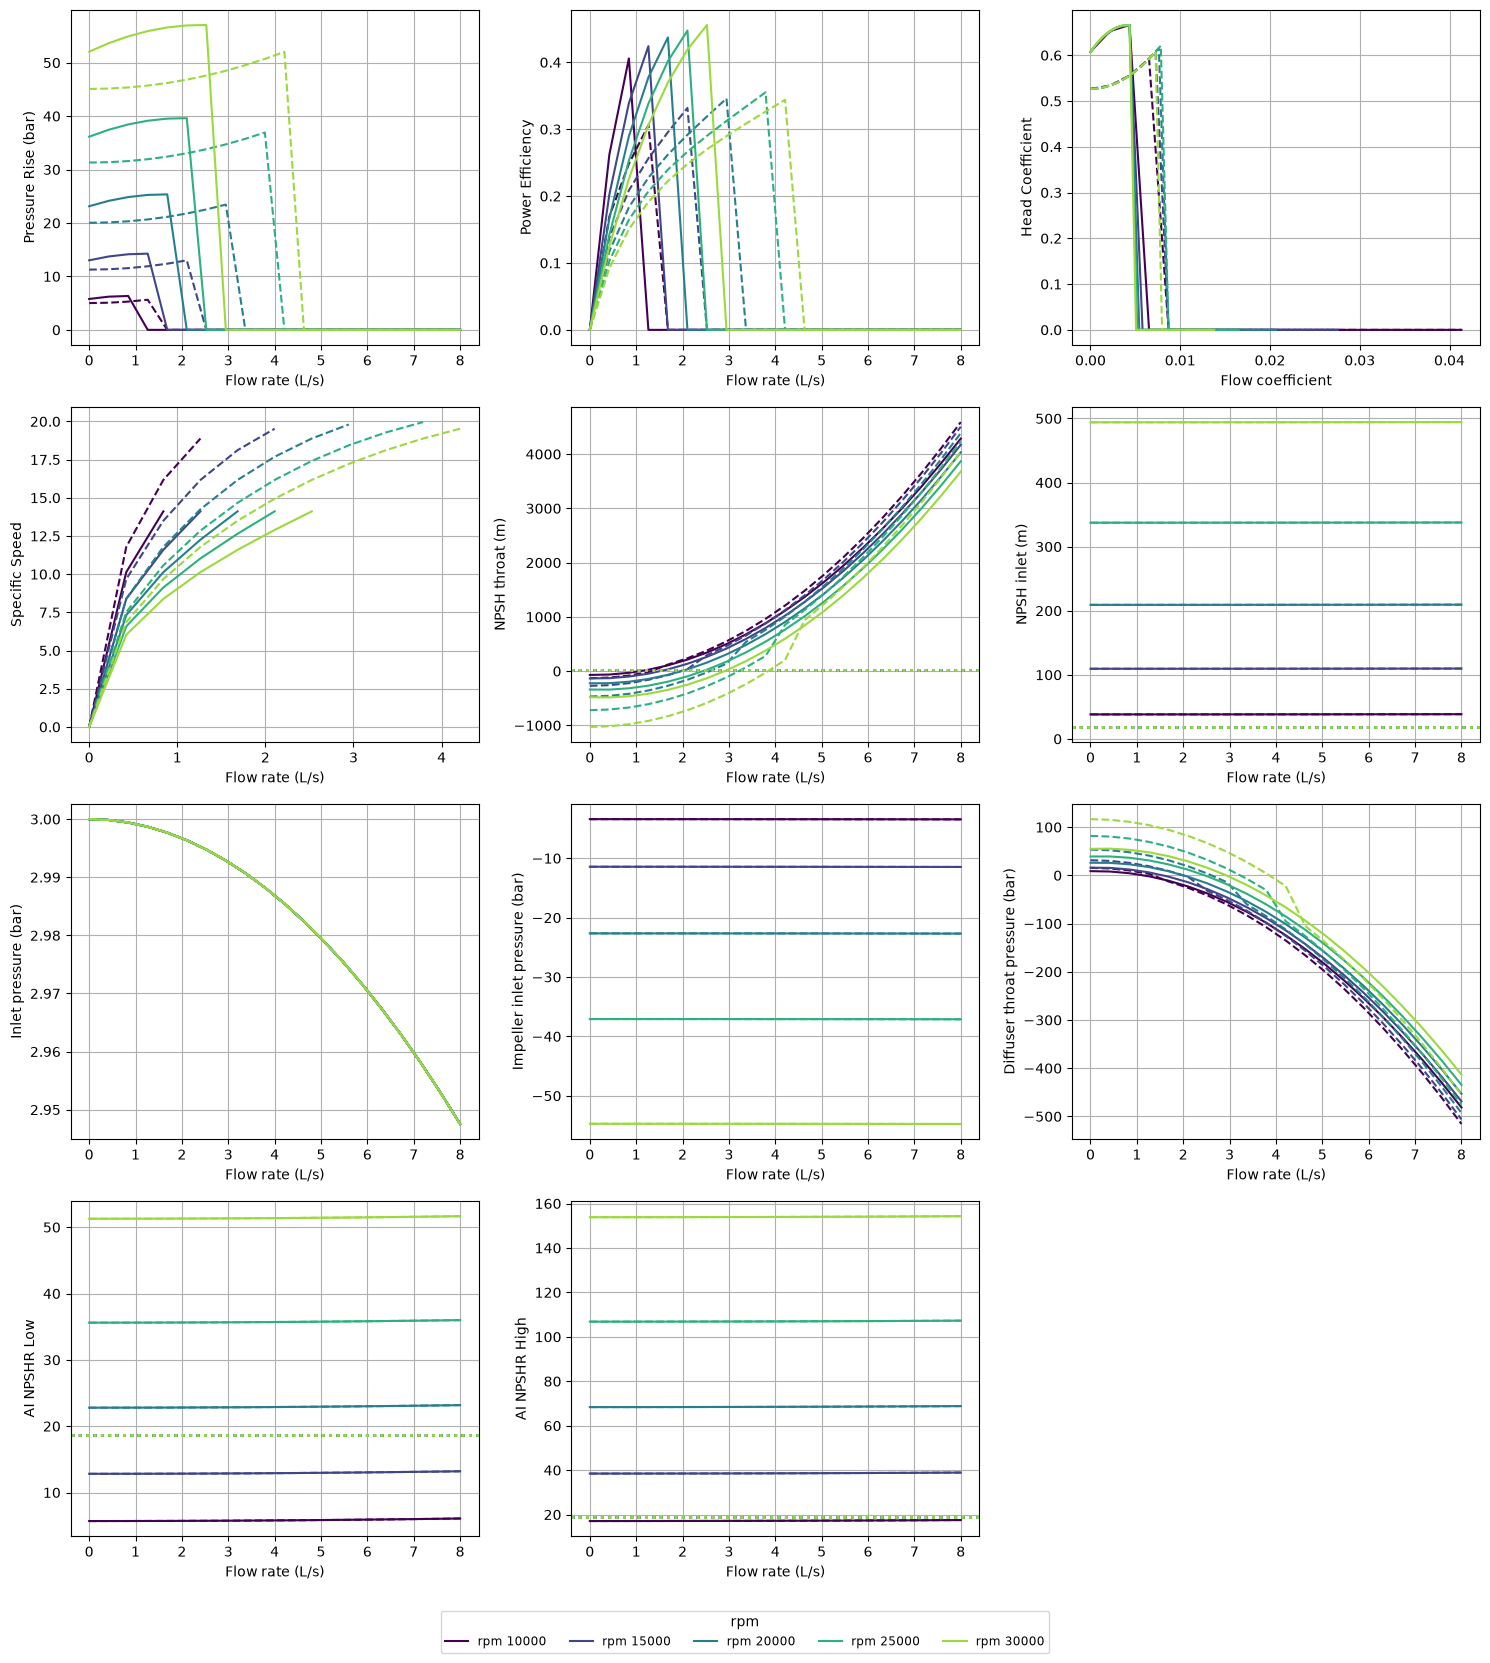

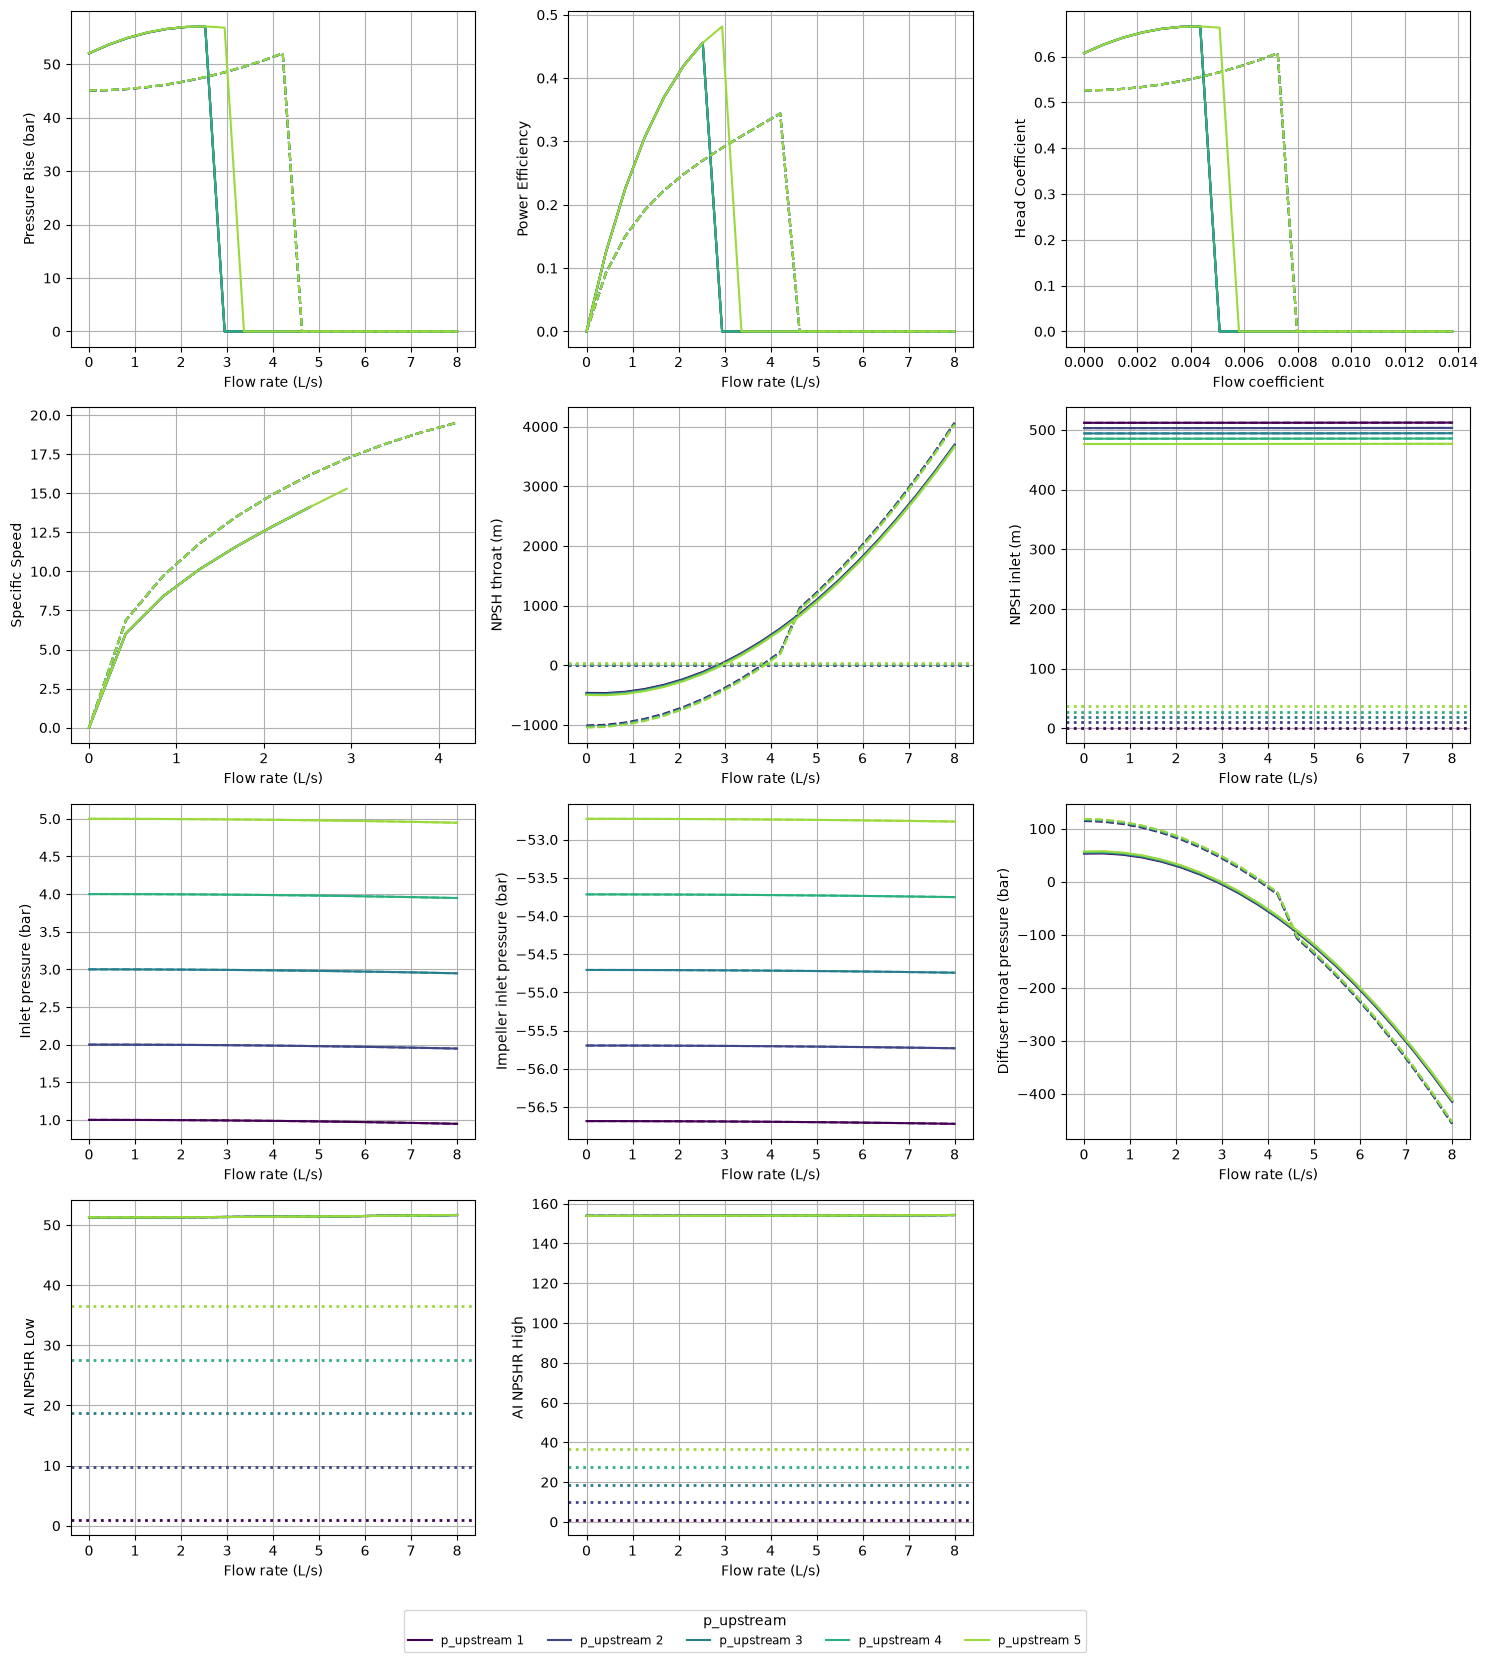

In [162]:
lox = Propellant("LOX", FluidsList.Oxygen, t_tank=89, p_tank=3)
rp1 = Propellant("RP-1", FluidsList.nDodecane, t_tank=293.15, p_tank=3)

propcea = PropCEA(lox, rp1)
engine_req = EngineRequirements(F=12000, p_a_bar=1.01325)
engine_choices = EngineChoices(OF=2, p_c_bar=50, p_e_bar=1, perc_film=0.1)
injector_choices = InjectorChoices(inj_dp=10, fuel_cd=0.8, ox_cd=0.8)
engine_calib = EngineCalibration(eff_cstar=0.95)
chamber, injector = size_engine(engine_req, engine_choices, injector_choices, engine_calib, propcea)
engine = Engine(chamber, injector, propcea, engine_calib)
engine_perf = engine.point_performance(p_c_bar=50, p_a_bar=1.01325, OF=2)
ox_pump_req = PumpRequirements.from_engine_perf(engine_perf, "ox")
ox_pump_choices = PumpChoices(rpm=30000, n_blades=6)
ox_pump_geometry = size_pump(ox_pump_req, ox_pump_choices, sizing_method="lock")
ox_pump = Pump(ox_pump_req, ox_pump_choices, ox_pump_geometry)

# _ok = lambda p: p.H_total_real > 0          # hide post-cutoff garbage
_ok = lambda p: True
PANELS = [
    Panel("Pressure Rise (bar)", "Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.dp),
    Panel("Power Efficiency",    "Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.eta_power),
    Panel("Head Coefficient",    "Flow coefficient", lambda p: p.flow_coeff_outlet, lambda p: p.head_coeff),
    Panel("Specific Speed",      "Flow rate (L/s)", lambda p: p.Q*1000,
          lambda p: p.rpm*np.sqrt(p.Q)/p.H_total_real**0.75 if p.H_total_real > 0 else np.nan),
    Panel("NPSH throat (m)",     "Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.npsh_r_throat,
          ref=lambda p: p.npsh_a_upstream, mask=_ok),
    Panel("NPSH inlet (m)",      "Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.npsh_r_inlet,
          ref=lambda p: p.npsh_a_upstream),
    Panel("Inlet pressure (bar)",          "Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.p_inlet),
    Panel("Impeller inlet pressure (bar)", "Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.p_1),
    Panel("Diffuser throat pressure (bar)","Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.p_throat, mask=_ok),
    Panel("AI NPSHR Low", "Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.npsh_r_ai_low, ref=lambda p: p.npsh_a_upstream),
    Panel("AI NPSHR High", "Flow rate (L/s)", lambda p: p.Q*1000, lambda p: p.npsh_r_ai_high, ref=lambda p: p.npsh_a_upstream)
]

sweep_plot(ox_pump, PANELS, Qs=np.linspace(0, 8e-3, 20),
           sweep=("rpm", [10000, 15000, 20000, 25000, 30000]),
           fixed=dict(propellant=lox, p_upstream=lox.p_tank, T_upstream=lox.t_tank),
           methods=["lock", "barske"])

sweep_plot(ox_pump, PANELS, Qs=np.linspace(0, 8e-3, 20),
           sweep=("p_upstream", [1, 2, 3, 4, 5]),
           fixed=dict(propellant=lox, rpm=30000, T_upstream=lox.t_tank),
           methods=["lock", "barske"])

print("Done")